# **Librerías**

In [96]:
# Importamos librerías a utilizar

# --- Librerías base ---
import math
import warnings
import numpy as np
import pandas as pd
from pandas import DataFrame
from collections import Counter

warnings.simplefilter('ignore')

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from IPython.display import display

# --- Preprocesamiento ---
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# --- Selección de modelos y validación ---
from sklearn.model_selection import (
    train_test_split, cross_validate,
    GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from scipy.stats import loguniform, uniform

# --- Modelos de regresión ---
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, SGDRegressor

# --- Modelos de clasificación ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans

# --- Métricas ---
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, root_mean_squared_error, r2_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

# --- Pipeline y composición ---
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight

# --- Balanceo de clases ---
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

# --- Deep Learning ---
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# --- Explicabilidad ---
import shap

# --- Utilidades ---
import joblib
import re

I0000 00:00:1776362028.975151    1107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776362028.987692    1107 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776362030.254237    1107 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776362034.914771    1107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# **Carga de dataset**

In [97]:
file_path='weatherAUS.csv'

df = pd.read_csv(file_path)

# **1. EDA**

## Filtro de ciudades

In [98]:
# Ciudades a utilizar
locations = ['Albury','Sydney','SydneyAirport','Canberra','Melbourne','MelbourneAirport']

# Filtrar el DataFrame
df = df[df['Location'].isin(locations)].reset_index(drop=True)

In [99]:
df['Location'].unique()

<StringArray>
[          'Albury',           'Sydney',    'SydneyAirport',
         'Canberra', 'MelbourneAirport',        'Melbourne']
Length: 6, dtype: str

## Creación de RainfallTomorrow

In [100]:
# Se ordenan los datos cronológicamente por Location y Date para asegurar que la variable objetivo se asigne correctamente
df = df.sort_values(by=['Location', 'Date']).reset_index(drop=True)

# Se crea la variable objetivo de regresión 'RainfallTomorrow: el Rainfall del día siguiente para cada Location
df['RainfallTomorrow'] = df.groupby('Location')['Rainfall'].shift(-1)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19031 entries, 0 to 19030
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              19031 non-null  str    
 1   Location          19031 non-null  str    
 2   MinTemp           18529 non-null  float64
 3   MaxTemp           18534 non-null  float64
 4   Rainfall          18215 non-null  float64
 5   Evaporation       14284 non-null  float64
 6   Sunshine          14042 non-null  float64
 7   WindGustDir       17542 non-null  str    
 8   WindGustSpeed     17544 non-null  float64
 9   WindDir9am        17811 non-null  str    
 10  WindDir3pm        18695 non-null  str    
 11  WindSpeed9am      18761 non-null  float64
 12  WindSpeed3pm      18771 non-null  float64
 13  Humidity9am       18452 non-null  float64
 14  Humidity3pm       18498 non-null  float64
 15  Pressure9am       18291 non-null  float64
 16  Pressure3pm       18297 non-null  float64
 17  Clou

In [102]:
# Se obtiene Month a partir de Date para luego usarlo en las imputaciones de valores faltantes
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

In [103]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow,Month
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,0.0,12
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,0.0,12
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,0.0,12
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,1.0,12
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,0.2,12


## Renombramiento de variables

In [104]:
# Se renombran las columnas para incluir sus unidades
unidades = {
    'MinTemp': 'MinTemp (°C)', 'MaxTemp': 'MaxTemp (°C)',
    'Rainfall': 'RainfallToday (mm)', 'Evaporation': 'Evaporation (mm)',
    'Sunshine': 'Sunshine (h)', 'WindGustSpeed': 'WindGustSpeed (km/h)',
    'WindSpeed9am': 'WindSpeed9am (km/h)', 'WindSpeed3pm': 'WindSpeed3pm (km/h)',
    'Humidity9am': 'Humidity9am (%)', 'Humidity3pm': 'Humidity3pm (%)',
    'Pressure9am': 'Pressure9am (hPa)', 'Pressure3pm': 'Pressure3pm (hPa)',
    'Cloud9am': 'Cloud9am (oktas)', 'Cloud3pm': 'Cloud3pm (oktas)',
    'Temp9am': 'Temp9am (°C)', 'Temp3pm': 'Temp3pm (°C)', 'RainfallTomorrow': 'RainfallTomorrow (mm)'
}

df.rename(columns=unidades, inplace=True)

## Análisis de valores faltantes y visualizaciones

In [105]:
def porcentaje_nan(df):
    cant_nan = df.isna().sum()
    porcentaje_nan = (cant_nan / len(df)) * 100

    info_nan = pd.DataFrame({
        'Cantidad': cant_nan,
        'Porcentaje': porcentaje_nan
    })

    info_nan['Porcentaje'] = info_nan['Porcentaje'].apply(lambda x: f"{x:.2f}%")

    print(info_nan)

porcentaje_nan(df)

                       Cantidad Porcentaje
Date                          0      0.00%
Location                      0      0.00%
MinTemp (°C)                502      2.64%
MaxTemp (°C)                497      2.61%
RainfallToday (mm)          816      4.29%
Evaporation (mm)           4747     24.94%
Sunshine (h)               4989     26.22%
WindGustDir                1489      7.82%
WindGustSpeed (km/h)       1487      7.81%
WindDir9am                 1220      6.41%
WindDir3pm                  336      1.77%
WindSpeed9am (km/h)         270      1.42%
WindSpeed3pm (km/h)         260      1.37%
Humidity9am (%)             579      3.04%
Humidity3pm (%)             533      2.80%
Pressure9am (hPa)           740      3.89%
Pressure3pm (hPa)           734      3.86%
Cloud9am (oktas)           4429     23.27%
Cloud3pm (oktas)           4546     23.89%
Temp9am (°C)                514      2.70%
Temp3pm (°C)                504      2.65%
RainToday                   816      4.29%
RainTomorro

--- REPORTE DE LIMPIEZA ---
Registros iniciales: 19031
1. Cantidad de datos eliminados con más del 50% faltantes: 489
2. Cantidad de datos eliminados con valores faltantes en RainTomorrow o RainfallTomorrow: 336
3. Porcentaje de datos eliminados sobre total inicial: 4.34%
Registros totales finales: 18206


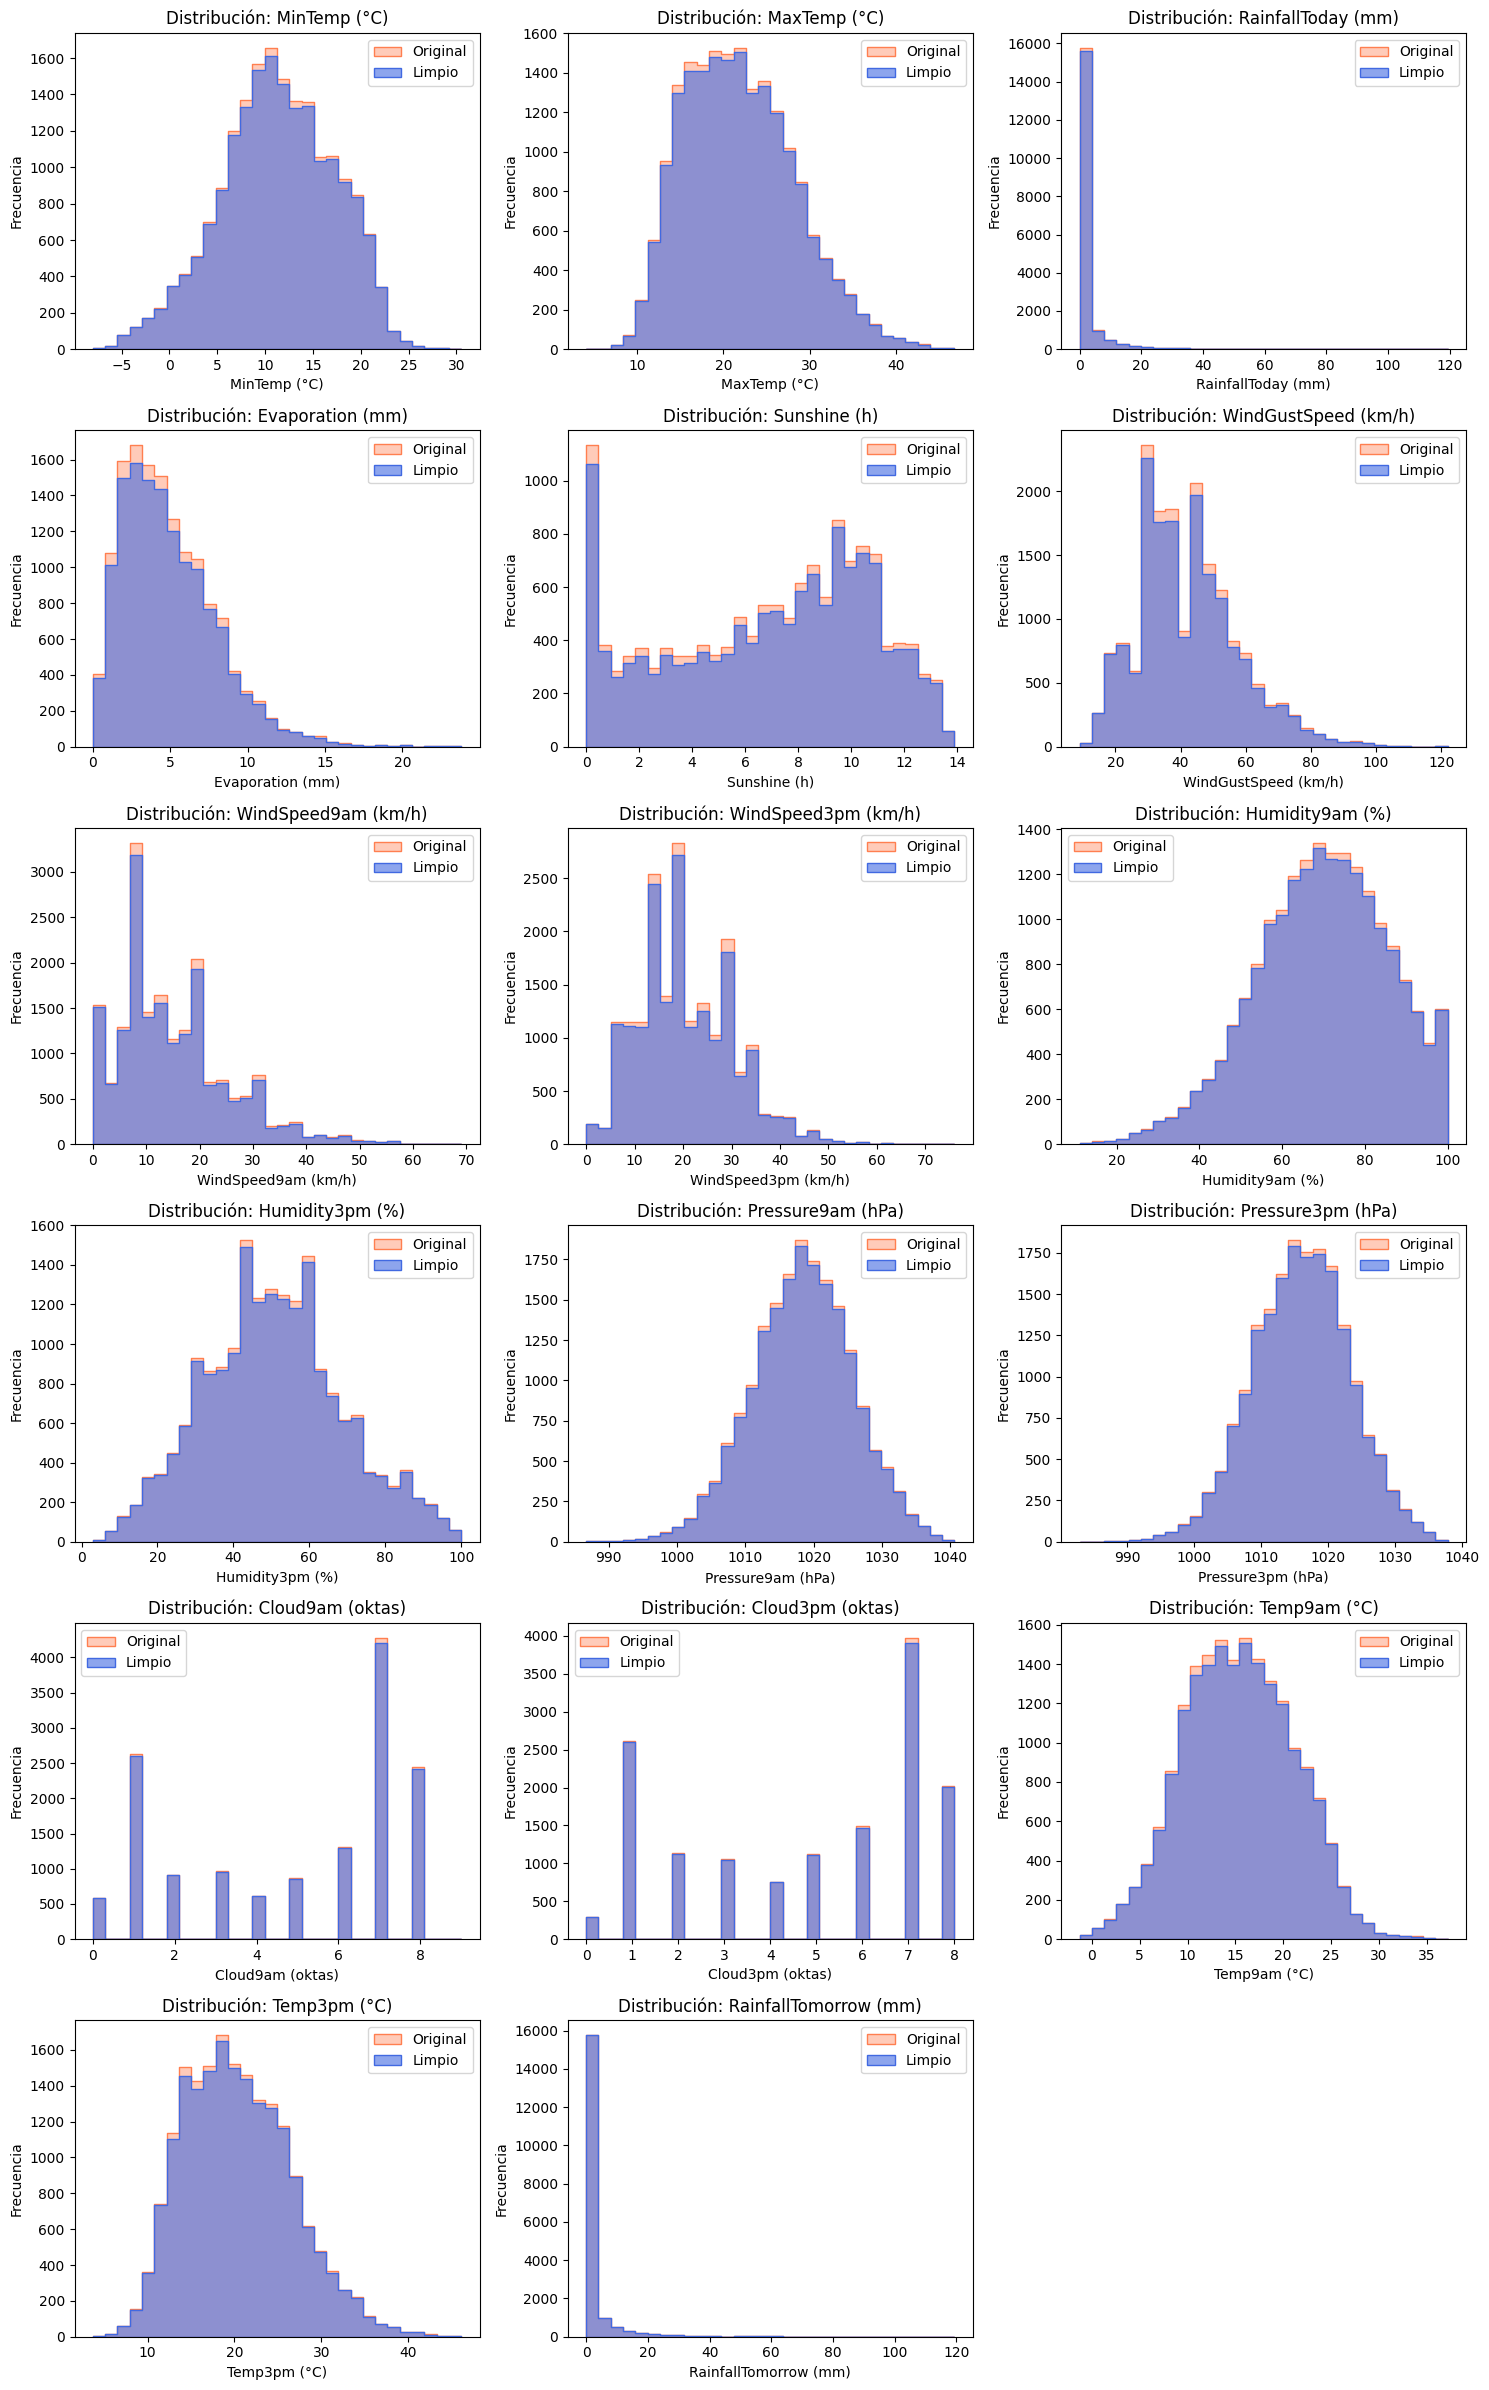

In [106]:
# Se guarda estado inicial para comparar
df_original = df.copy()
total_inicial = len(df)

# Se eliminan filas que contengan Nan en más de la mitad de las columnas
df = df.dropna(thresh=df.shape[1] // 2)
filas = len(df)

# Se eliminan filas con valores Nan en RainTomorrow o RainfallTomorrow
targets = ['RainTomorrow', 'RainfallTomorrow (mm)']
df = df.dropna(subset=targets).reset_index(drop=True)
filas_finales = len(df)


print(f"--- REPORTE DE LIMPIEZA ---")
print(f"Registros iniciales: {total_inicial}")
print(f"1. Cantidad de datos eliminados con más del 50% faltantes: {total_inicial - filas}")
print(f"2. Cantidad de datos eliminados con valores faltantes en RainTomorrow o RainfallTomorrow: {filas - filas_finales}")
print(f"3. Porcentaje de datos eliminados sobre total inicial: {((total_inicial - filas_finales)*100/total_inicial):.2f}%")
print(f"Registros totales finales: {filas_finales}")

# Visualizaciones
cols_num = [c for c in df.columns if '(' in c]
n_cols = 3
n_filas = (len(cols_num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_filas, n_cols, figsize=(15, n_filas * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    # Histogramas con bins=30
    sns.histplot(df_original[col], color="coral", label="Original",
                 ax=axes[i], bins=30, element="step", alpha=0.4)

    sns.histplot(df[col], color="royalblue", label="Limpio",
                 ax=axes[i], bins=30, element="step", alpha=0.6)

    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Limpiar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [107]:
# Mapeo de direcciones cardinales a grados
wind_dir_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

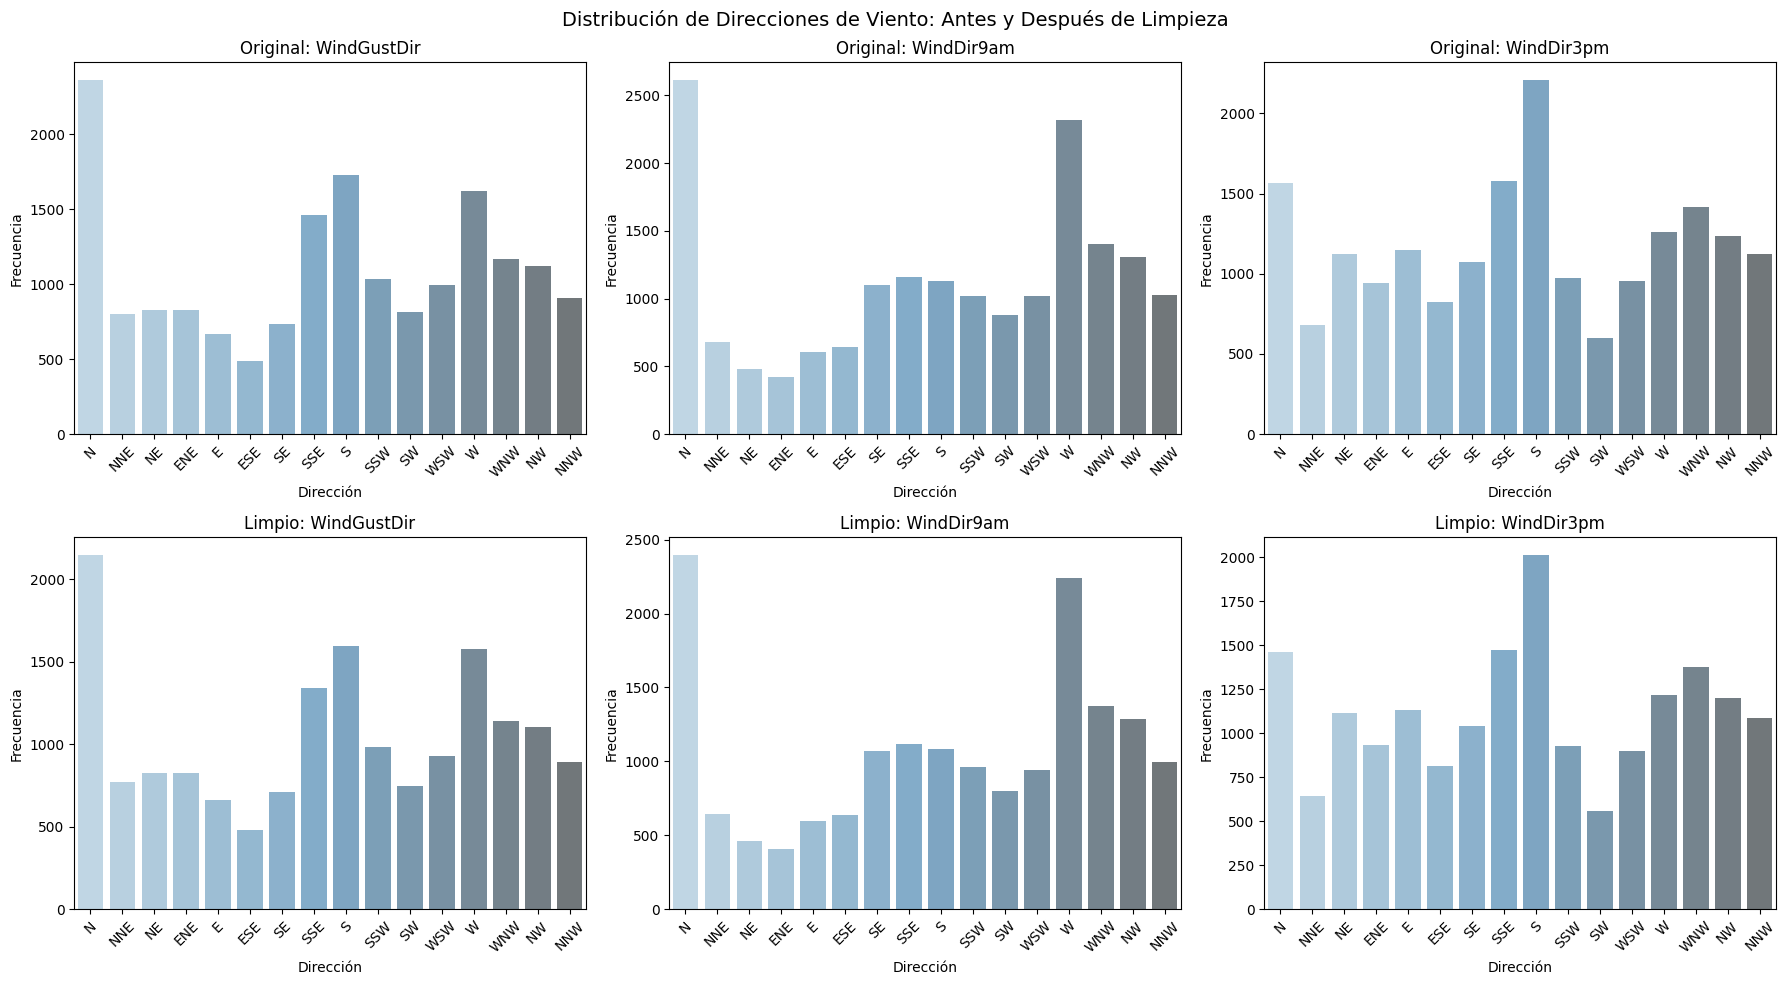

In [108]:
# Distribución de frecuencia de direcciones de viento (antes y después de limpieza)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
wind_cols_orig = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
order = list(wind_dir_map.keys())

for i, col in enumerate(wind_cols_orig):
    counts_orig = df_original[col].value_counts().reindex(order)
    counts_clean = df[col].value_counts().reindex(order)

    # Fila 1: Original
    sns.barplot(x=counts_orig.index, y=counts_orig.values, ax=axes[0, i], palette='Blues_d', alpha=0.7)
    axes[0, i].set_title(f'Original: {col}')
    axes[0, i].set_xlabel('Dirección')
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].tick_params(axis='x', rotation=45)

    # Fila 2: Limpio
    sns.barplot(x=counts_clean.index, y=counts_clean.values, ax=axes[1, i], palette='Blues_d', alpha=0.7)
    axes[1, i].set_title(f'Limpio: {col}')
    axes[1, i].set_xlabel('Dirección')
    axes[1, i].set_ylabel('Frecuencia')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de Direcciones de Viento: Antes y Después de Limpieza', fontsize=14)
plt.tight_layout()
plt.show()

El reporte de limpieza dio como resultado un descarte del 4.34% del volumen inicial del dataset, garantizando que sigue siendo estadísticamente representativo de las ciudades seleccionadas.
Además, al comparar las distribuciones de las variables climáticas antes y después de la limpieza, se observa que no hubo desplazamientos significativos en las medias ni en las varianzas. Esto confirma que el proceso de limpieza fue no sesgado, preservando la naturaleza del fenómeno meteorológico.

In [109]:
porcentaje_nan(df)

                       Cantidad Porcentaje
Date                          0      0.00%
Location                      0      0.00%
MinTemp (°C)                 13      0.07%
MaxTemp (°C)                  7      0.04%
RainfallToday (mm)          183      1.01%
Evaporation (mm)           4704     25.84%
Sunshine (h)               4946     27.17%
WindGustDir                1452      7.98%
WindGustSpeed (km/h)       1450      7.96%
WindDir9am                 1192      6.55%
WindDir3pm                  327      1.80%
WindSpeed9am (km/h)         261      1.43%
WindSpeed3pm (km/h)         253      1.39%
Humidity9am (%)              89      0.49%
Humidity3pm (%)              49      0.27%
Pressure9am (hPa)           250      1.37%
Pressure3pm (hPa)           246      1.35%
Cloud9am (oktas)           3767     20.69%
Cloud3pm (oktas)           3875     21.28%
Temp9am (°C)                 25      0.14%
Temp3pm (°C)                 20      0.11%
RainToday                   183      1.01%
RainTomorro

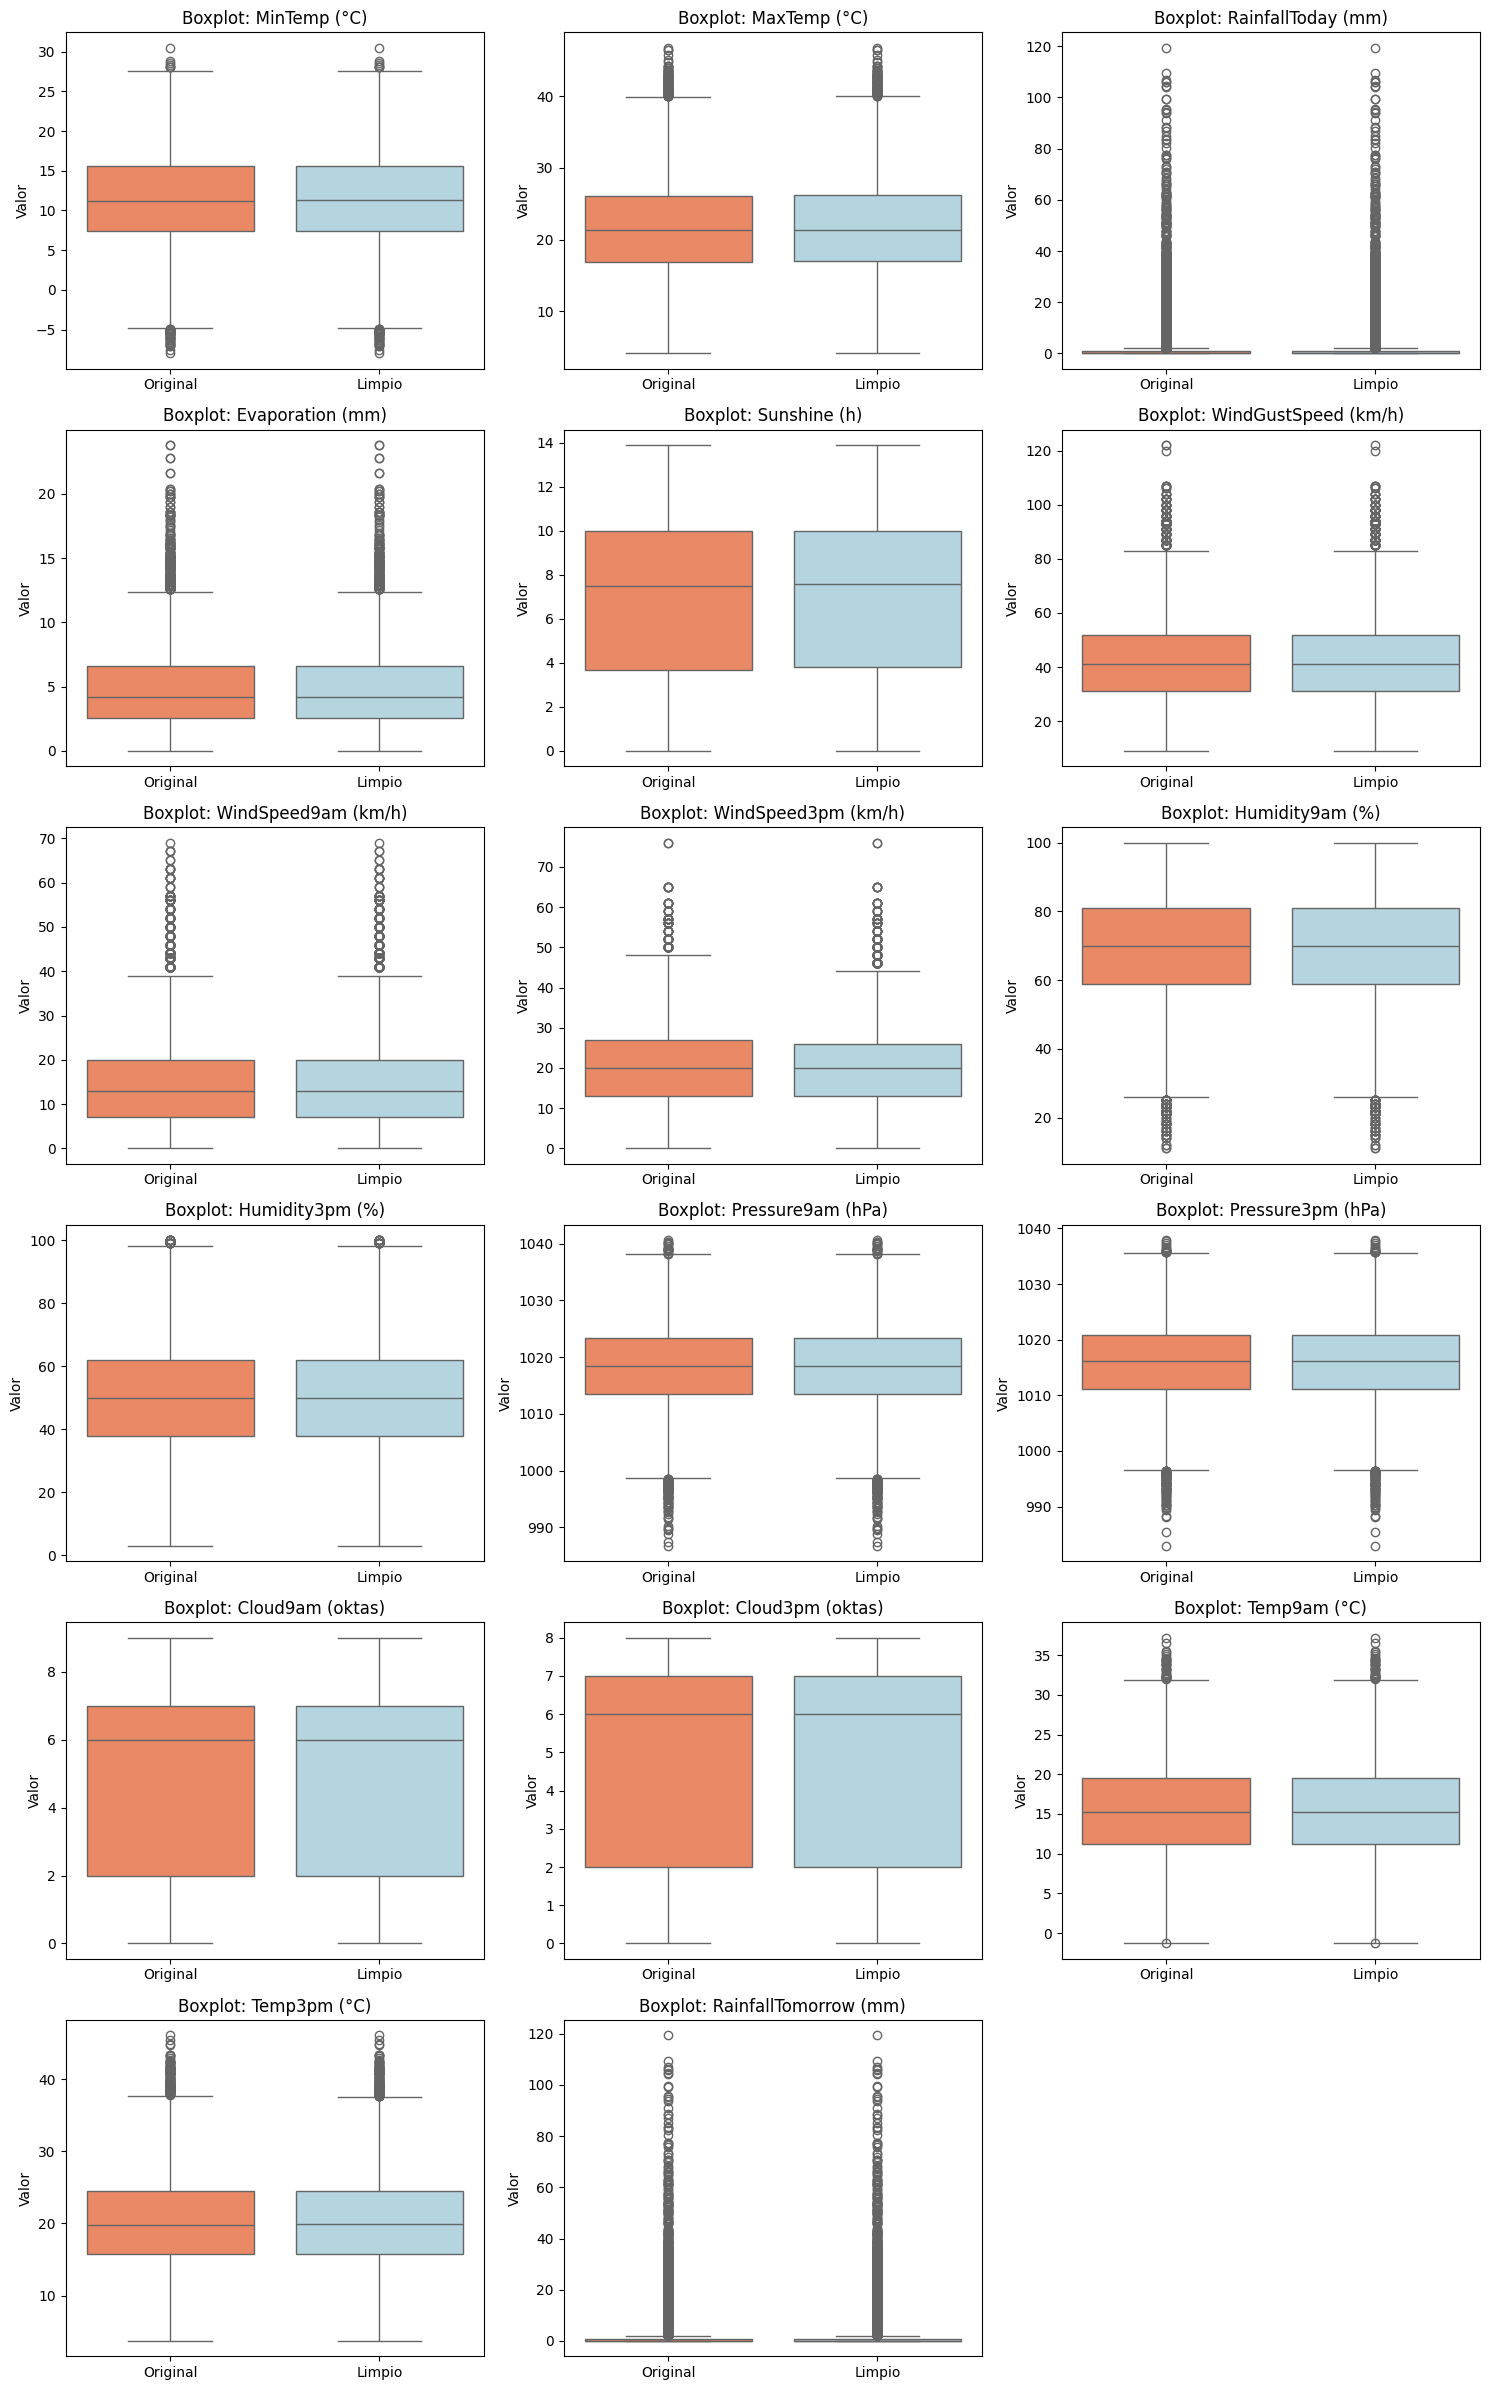

In [110]:
# Boxplots
fig, axes = plt.subplots(n_filas, n_cols, figsize=(15, n_filas * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    temp_df = pd.concat([
        pd.DataFrame({col: df_original[col], 'Estado': 'Original'}),
        pd.DataFrame({col: df[col], 'Estado': 'Limpio'})
    ]).reset_index(drop=True)

    sns.boxplot(data=temp_df, x='Estado', y=col, ax=axes[i],
                palette={'Original': 'coral', 'Limpio': 'lightblue'},
                hue='Estado', legend=False)

    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor')

# Limpiar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Con estos boxplots se confirma lo analizado en la visualización de distribuciones anterior, que las mismas no fueron afectadas por la limpieza inicial. A su vez, se pueden observar valores atípicos en algunas variables propios de las características climáticas que representan.

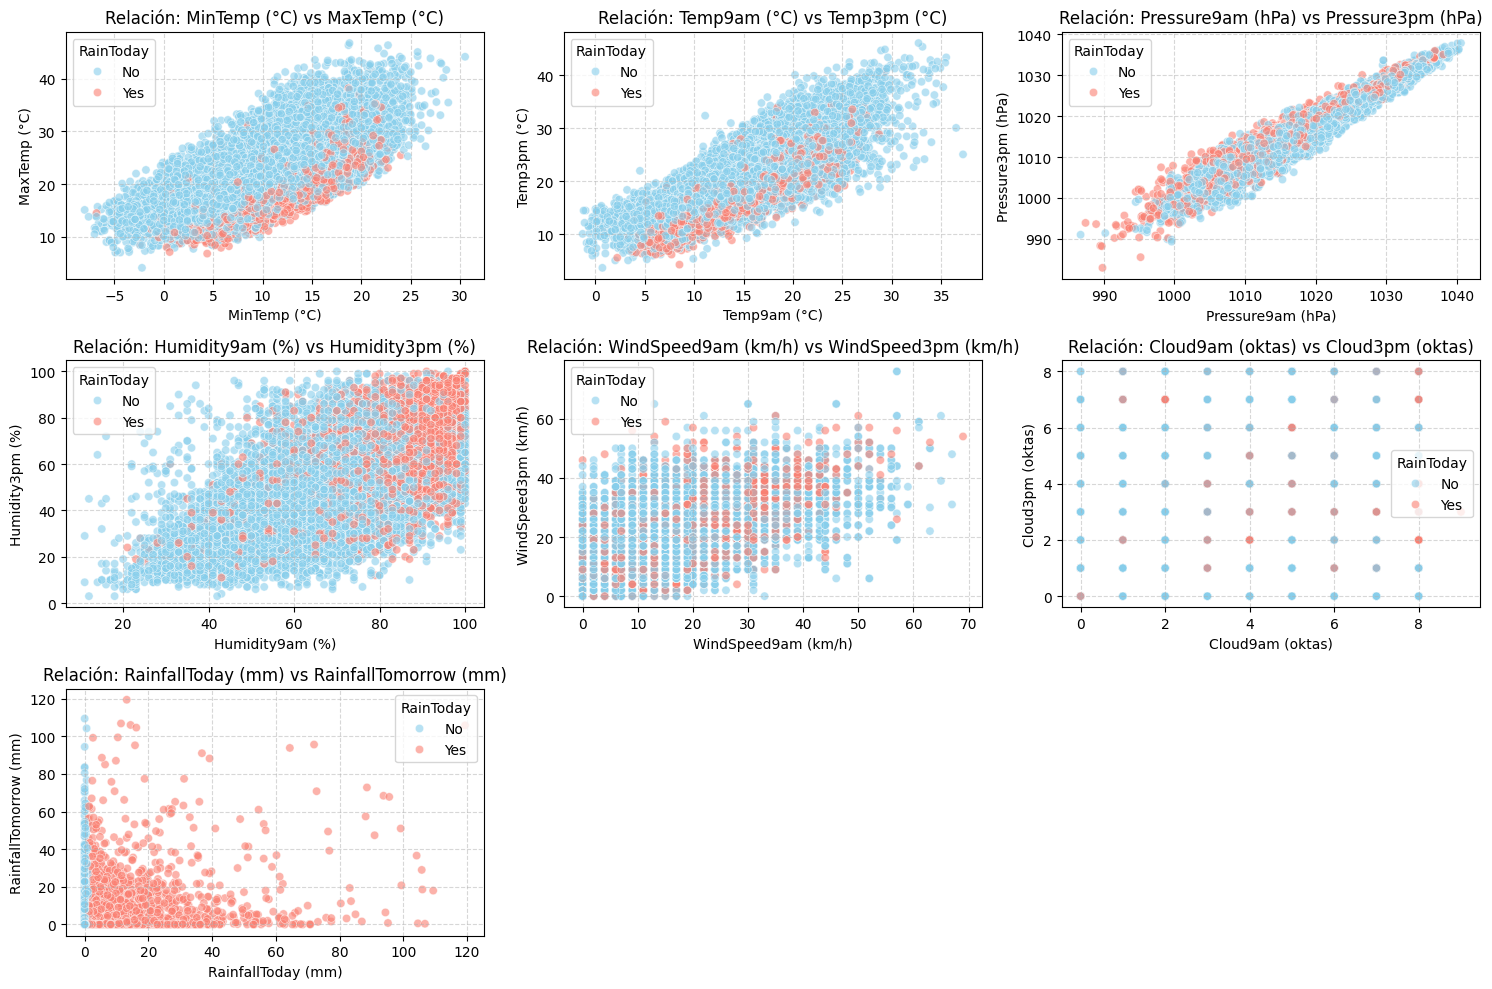

In [111]:
# Scatterplots para variables relacionadas
pares_similares = [
    ('MinTemp (°C)', 'MaxTemp (°C)'),
    ('Temp9am (°C)', 'Temp3pm (°C)'),
    ('Pressure9am (hPa)', 'Pressure3pm (hPa)'),
    ('Humidity9am (%)', 'Humidity3pm (%)'),
    ('WindSpeed9am (km/h)', 'WindSpeed3pm (km/h)'),
    ('Cloud9am (oktas)', 'Cloud3pm (oktas)'),
    ('RainfallToday (mm)', 'RainfallTomorrow (mm)')
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (col_x, col_y) in enumerate(pares_similares):
    # Se grafican si ambas columnas existen en el dataframe
    if col_x in df.columns and col_y in df.columns:
        sns.scatterplot(
            data=df,
            x=col_x,
            y=col_y,
            hue='RainToday',
            palette={'No': 'skyblue', 'Yes': 'salmon'},
            alpha=0.6,
            ax=axes[i]
        )
        axes[i].set_title(f'Relación: {col_x} vs {col_y}')
        axes[i].grid(True, linestyle='--', alpha=0.5)


# Limpiar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar diseño
plt.tight_layout()
plt.show()

Los primeros tres scatterplots muestran una correlación lineal fuerte entre los pares de variables aunque la separación de clases (RainToday Yes/No) no es clara, por lo que estas variables no discriminan bien la lluvia por si solas.
En el caso de la humedad, los datos estás más dispersos, reflejando una relación menos lineal. Se puede observar que los valores altos de humedad se asocian más a días lluviosos.
WindSpeed9am vs WindSpeed3pm
Tanto los valores de la velocidad del viento como los de nubosidad son discretos, lo que da como resultado que los puntos se apilen en líneas, dando una apariencia de cuadrícula. 
El scatterplot de Rainfall muestra una alta concentración de valores en 0, con cola larga a la derecha, lo que dificulta su lectura.

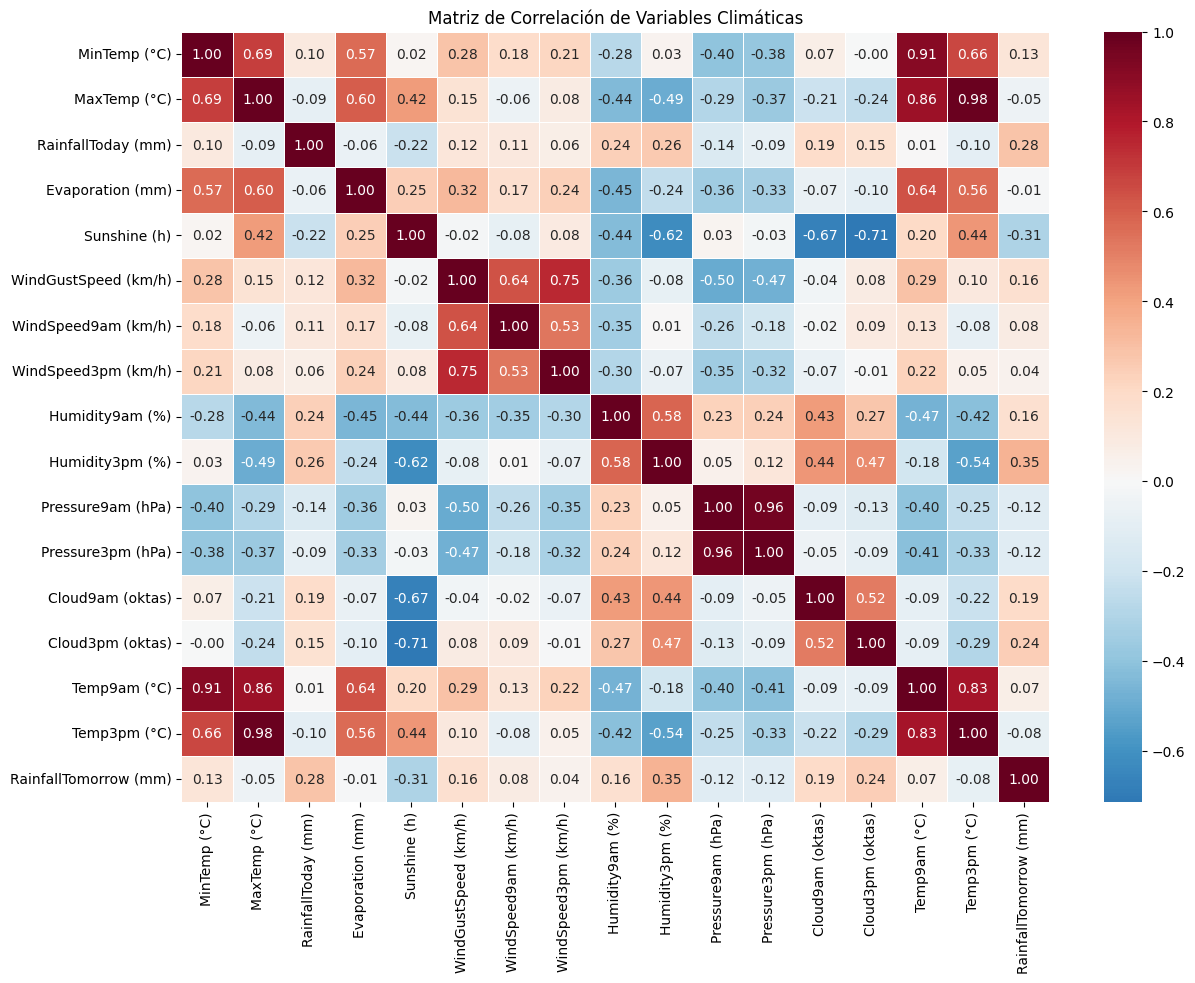

In [112]:
# --- Matriz de Correlación ---
plt.figure(figsize=(14, 10))

# Calculamos la correlación solo para variables numéricas
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Creamos el mapa de calor
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)

plt.title('Matriz de Correlación de Variables Climáticas')
plt.show()

En cuanto a las correlaciones positivas más fuertes, se destaca la relación entre Pressure9am y Pressure3pm, lo que indica que la presión atmosférica se mantiene estable a lo largo del día. Lo mismo sucedde con MinTemp y Temp9am, y con MaxTemp y Temp3pm, confirmando que la temperatura mínima diaria ocurre en las primeras horas de la mañana y que la temperatura máxima se alcanza cerca de las 3pm. WindGustSpeed y WindSpeed3pm también muestran una correlación alta, sugiriendo que las ráfagas de viento más intensas ocurren durante la tarde.

Respecto a las correlaciones negativas más relevantes, Sunshine presenta relaciones inversas con Cloud9am y Cloud3pm, lo que es físicamente esperado: a mayor nubosidad, menor cantidad de horas de sol. También se observa algo similar entre Humidity3pm y Sunshine, indicando que los días más soleados tienden a ser menos húmedos.

En relación a la variable objetivo RainfallTomorrow, ninguna variable supera una correlación de 0.35, siendo Humidity3pm y Sunshine las más relevantes. Esto evidencia que la lluvia del día siguiente no tiene una dependencia lineal fuerte con ninguna variable individual, lo que justifica el uso de modelos más complejos con mayor capacidad de capturar relaciones no lineales.

Finalmente, la alta correlación entre pares como MinTemp/Temp9am, MaxTemp/Temp3pm y Pressure9am/Pressure3pm introduce multicolinealidad, aportando información redundante en modelos de regresión lineal. Esto refuerza la importancia de aplicar técnicas de regularización.

## Split incial train - test

In [113]:
# Se separan variables predictoras y variables objetivo
X = df.drop(columns=['RainTomorrow', 'RainfallTomorrow (mm)', 'Date'])
y_reg = df['RainfallTomorrow (mm)']    # Objetivo para Regresión (Cantidad)
y_class = df['RainTomorrow']            # Objetivo para Clasificación (Yes/No)

# Train - test split para ambas targets
# Stratify=y_class para mantener la proporción de lluvia en los sets
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Verificación de que todo coincida
print(f"Filas en X_train: {len(X_train)}")
print(f"Filas en y_train_class: {len(y_train_class)}")
print(f"Filas en y_train_reg: {len(y_train_reg)}")

Filas en X_train: 14564
Filas en y_train_class: 14564
Filas en y_train_reg: 14564


## Imputación

In [114]:
def imputar_mediana(df_train, df_test, cols_mediana, n_neighbors=5):
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    for col in cols_mediana:
        # Mediana por Location y Month de Train
        dict_loc_month = df_train.groupby(['Location', 'Month'])[col].median().to_dict()
        # Mediana por Mes (promedio de todas las ciudades en ese mes)
        dict_month_only = df_train.groupby(['Month'])[col].median().to_dict()

        def apply_cascade(row):
            val = row[col]
            if pd.isna(val):
                val = dict_loc_month.get((row['Location'], row['Month']), np.nan)
                # Solo Mes (si el anterior fue NaN)
                if pd.isna(val):
                    val = dict_month_only.get(row['Month'], np.nan)
            return val

        # Aplicar en Train y Test
        df_train_imputed[col] = df_train_imputed.apply(apply_cascade, axis=1)
        df_test_imputed[col] = df_test_imputed.apply(apply_cascade, axis=1)

    return df_train_imputed, df_test_imputed

def imputar_knn(df_train, df_test, cols_knn, n_neighbors=5):
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    # KNN solo opera sobre variables numéricas
    numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    cols_knn_valid = [col for col in cols_knn if col in numeric_cols]

    if not cols_knn_valid:
        return df_train_imputed, df_test_imputed

    train_num = df_train[numeric_cols].copy()
    test_num = df_test[numeric_cols].copy()

    knn_imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
    train_num_imp = pd.DataFrame(
        knn_imputer.fit_transform(train_num),
        columns=numeric_cols,
        index=df_train.index
    )
    test_num_imp = pd.DataFrame(
        knn_imputer.transform(test_num),
        columns=numeric_cols,
        index=df_test.index
    )

    # Reemplazar solo celdas originalmente faltantes en las columnas seleccionadas
    for col in cols_knn_valid:
        missing_train = df_train[col].isna()
        missing_test = df_test[col].isna()

        df_train_imputed.loc[missing_train, col] = train_num_imp.loc[missing_train, col]
        df_test_imputed.loc[missing_test, col] = test_num_imp.loc[missing_test, col]

        # Cloud en oktas: forzar dominio discreto [0, 8]
        if col in ['Cloud9am (oktas)', 'Cloud3pm (oktas)']:
            df_train_imputed[col] = df_train_imputed[col].round().clip(0, 8)
            df_test_imputed[col] = df_test_imputed[col].round().clip(0, 8)

    return df_train_imputed, df_test_imputed

def imputar_moda(df_train, df_test, cols_moda):
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    for col in cols_moda:
        # Moda por Location y Month de Train
        dict_loc_month = df_train.groupby(['Location', 'Month'])[col].apply(
            lambda x: x.mode()[0] if not x.mode().empty else np.nan
        ).to_dict()
        # Moda por Mes (promedio de todas las ciudades en ese mes)
        dict_month_only = df_train.groupby(['Month'])[col].apply(
            lambda x: x.mode()[0] if not x.mode().empty else np.nan
        ).to_dict()

        def apply_cascade_cat(row):
            val = row[col]
            if pd.isna(val):
                val = dict_loc_month.get((row['Location'], row['Month']), np.nan)
                # Solo Mes (si el anterior fue NaN)
                if pd.isna(val):
                    val = dict_month_only.get(row['Month'], np.nan)
            return val

        # Aplicar en Train y Test
        df_train_imputed[col] = df_train_imputed.apply(apply_cascade_cat, axis=1)
        df_test_imputed[col] = df_test_imputed.apply(apply_cascade_cat, axis=1)

    return df_train_imputed, df_test_imputed

In [115]:
# División en columnas para imputación
cols_mediana = ['MinTemp (°C)', 'MaxTemp (°C)', 'RainfallToday (mm)', 'WindSpeed9am (km/h)',
                'WindSpeed3pm (km/h)', 'Humidity9am (%)', 'Humidity3pm (%)',
                'Pressure9am (hPa)', 'Pressure3pm (hPa)', 'Temp9am (°C)', 'Temp3pm (°C)']

cols_knn = ['Evaporation (mm)', 'Sunshine (h)', 'WindGustSpeed (km/h)', 'Cloud9am (oktas)', 'Cloud3pm (oktas)']

cols_moda = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [116]:
# Imputación de valores faltantes
X_train, X_test = imputar_mediana(X_train, X_test, cols_mediana)
X_train, X_test = imputar_knn(X_train, X_test, cols_knn)
X_train, X_test = imputar_moda(X_train, X_test, cols_moda)

### Verificación de la imputación

In [117]:
porcentaje_nan(X_train)

                      Cantidad Porcentaje
Location                     0      0.00%
MinTemp (°C)                 0      0.00%
MaxTemp (°C)                 0      0.00%
RainfallToday (mm)           0      0.00%
Evaporation (mm)             0      0.00%
Sunshine (h)                 0      0.00%
WindGustDir                  0      0.00%
WindGustSpeed (km/h)         0      0.00%
WindDir9am                   0      0.00%
WindDir3pm                   0      0.00%
WindSpeed9am (km/h)          0      0.00%
WindSpeed3pm (km/h)          0      0.00%
Humidity9am (%)              0      0.00%
Humidity3pm (%)              0      0.00%
Pressure9am (hPa)            0      0.00%
Pressure3pm (hPa)            0      0.00%
Cloud9am (oktas)             0      0.00%
Cloud3pm (oktas)             0      0.00%
Temp9am (°C)                 0      0.00%
Temp3pm (°C)                 0      0.00%
RainToday                    0      0.00%
Month                        0      0.00%


In [118]:
porcentaje_nan(X_test)

                      Cantidad Porcentaje
Location                     0      0.00%
MinTemp (°C)                 0      0.00%
MaxTemp (°C)                 0      0.00%
RainfallToday (mm)           0      0.00%
Evaporation (mm)             0      0.00%
Sunshine (h)                 0      0.00%
WindGustDir                  0      0.00%
WindGustSpeed (km/h)         0      0.00%
WindDir9am                   0      0.00%
WindDir3pm                   0      0.00%
WindSpeed9am (km/h)          0      0.00%
WindSpeed3pm (km/h)          0      0.00%
Humidity9am (%)              0      0.00%
Humidity3pm (%)              0      0.00%
Pressure9am (hPa)            0      0.00%
Pressure3pm (hPa)            0      0.00%
Cloud9am (oktas)             0      0.00%
Cloud3pm (oktas)             0      0.00%
Temp9am (°C)                 0      0.00%
Temp3pm (°C)                 0      0.00%
RainToday                    0      0.00%
Month                        0      0.00%


### Visualizaciones 

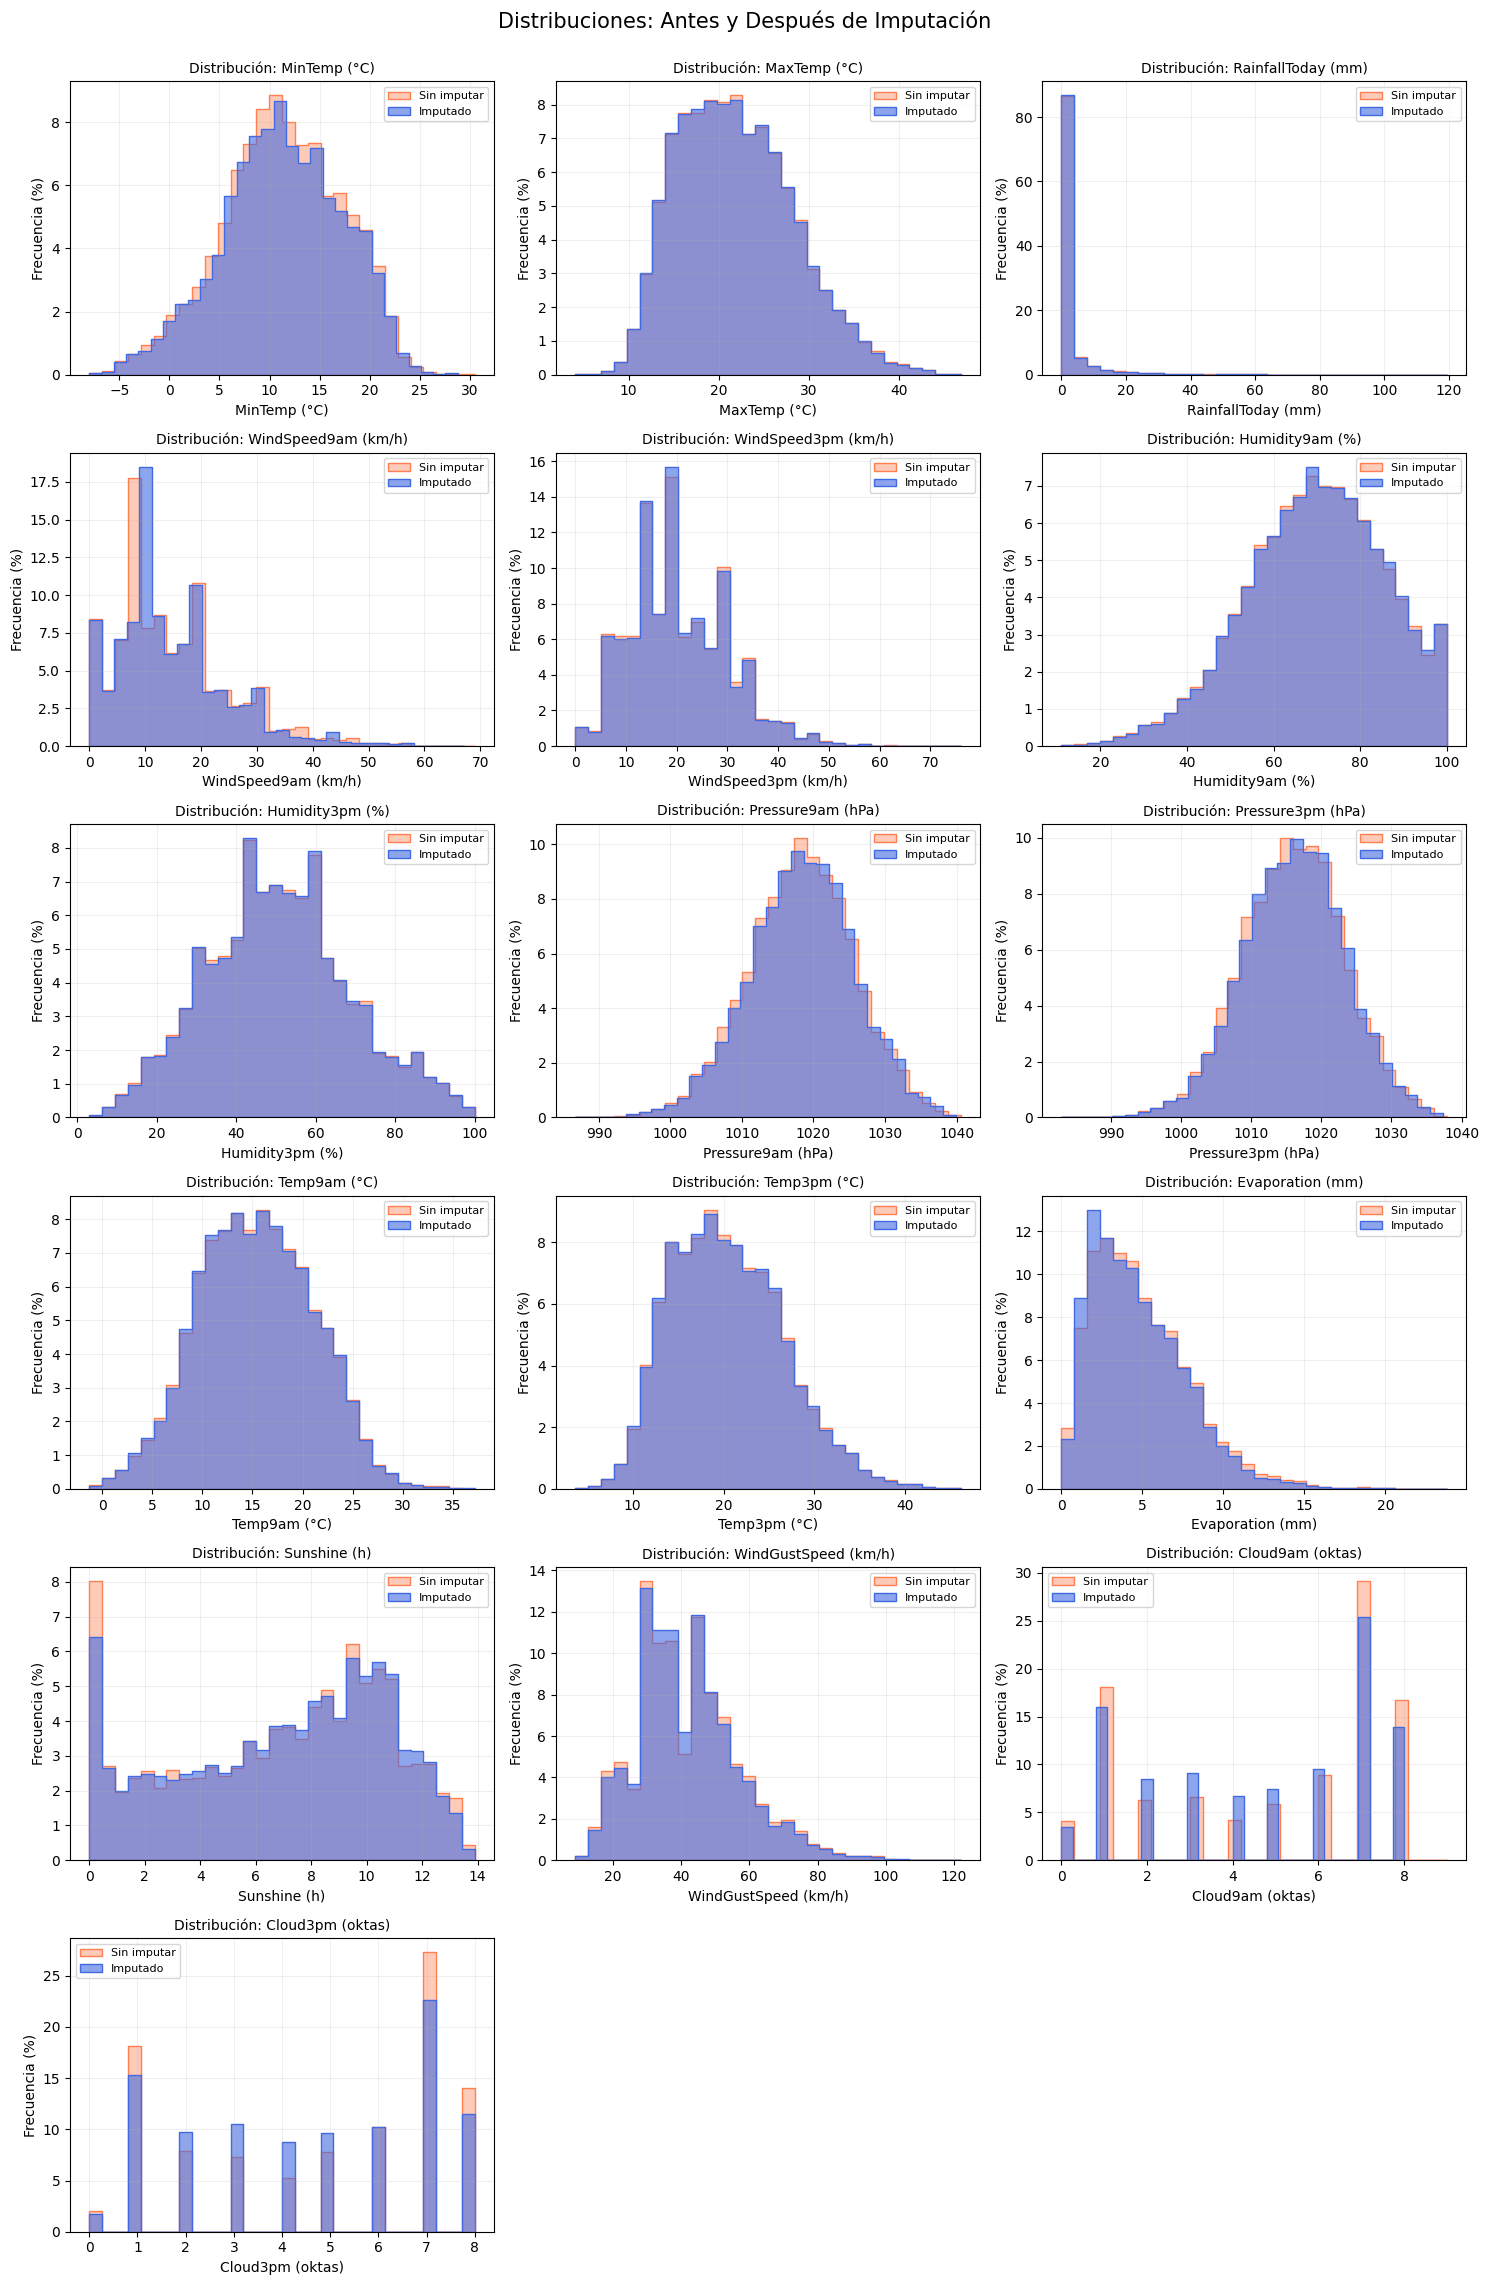

In [119]:
# ---- Histogramas: antes y después de imputación ----
# Usar solo las columnas que fueron imputadas
cols_num_imp = cols_mediana + cols_knn
n_filas_imp = (len(cols_num_imp) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_filas_imp, n_cols, figsize=(15, n_filas_imp * 3.8))
axes = axes.flatten()

for i, col in enumerate(cols_num_imp):
    sns.histplot(
        df[col],
        color="coral",
        label="Sin imputar",
        ax=axes[i],
        bins=30,
        element="step",
        alpha=0.4,
        stat="percent"
    )
    sns.histplot(
        X_train[col],
        color="royalblue",
        label="Imputado",
        ax=axes[i],
        bins=30,
        element="step",
        alpha=0.6,
        stat="percent"
    )

    axes[i].set_title(f"Distribución: {col}", fontsize=10)
    axes[i].set_ylabel("Frecuencia (%)")
    axes[i].grid(alpha=0.2)
    axes[i].legend(fontsize=8)

# Eliminar ejes vacíos si sobran subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribuciones: Antes y Después de Imputación", fontsize=15, y=1)
fig.tight_layout()
plt.show()

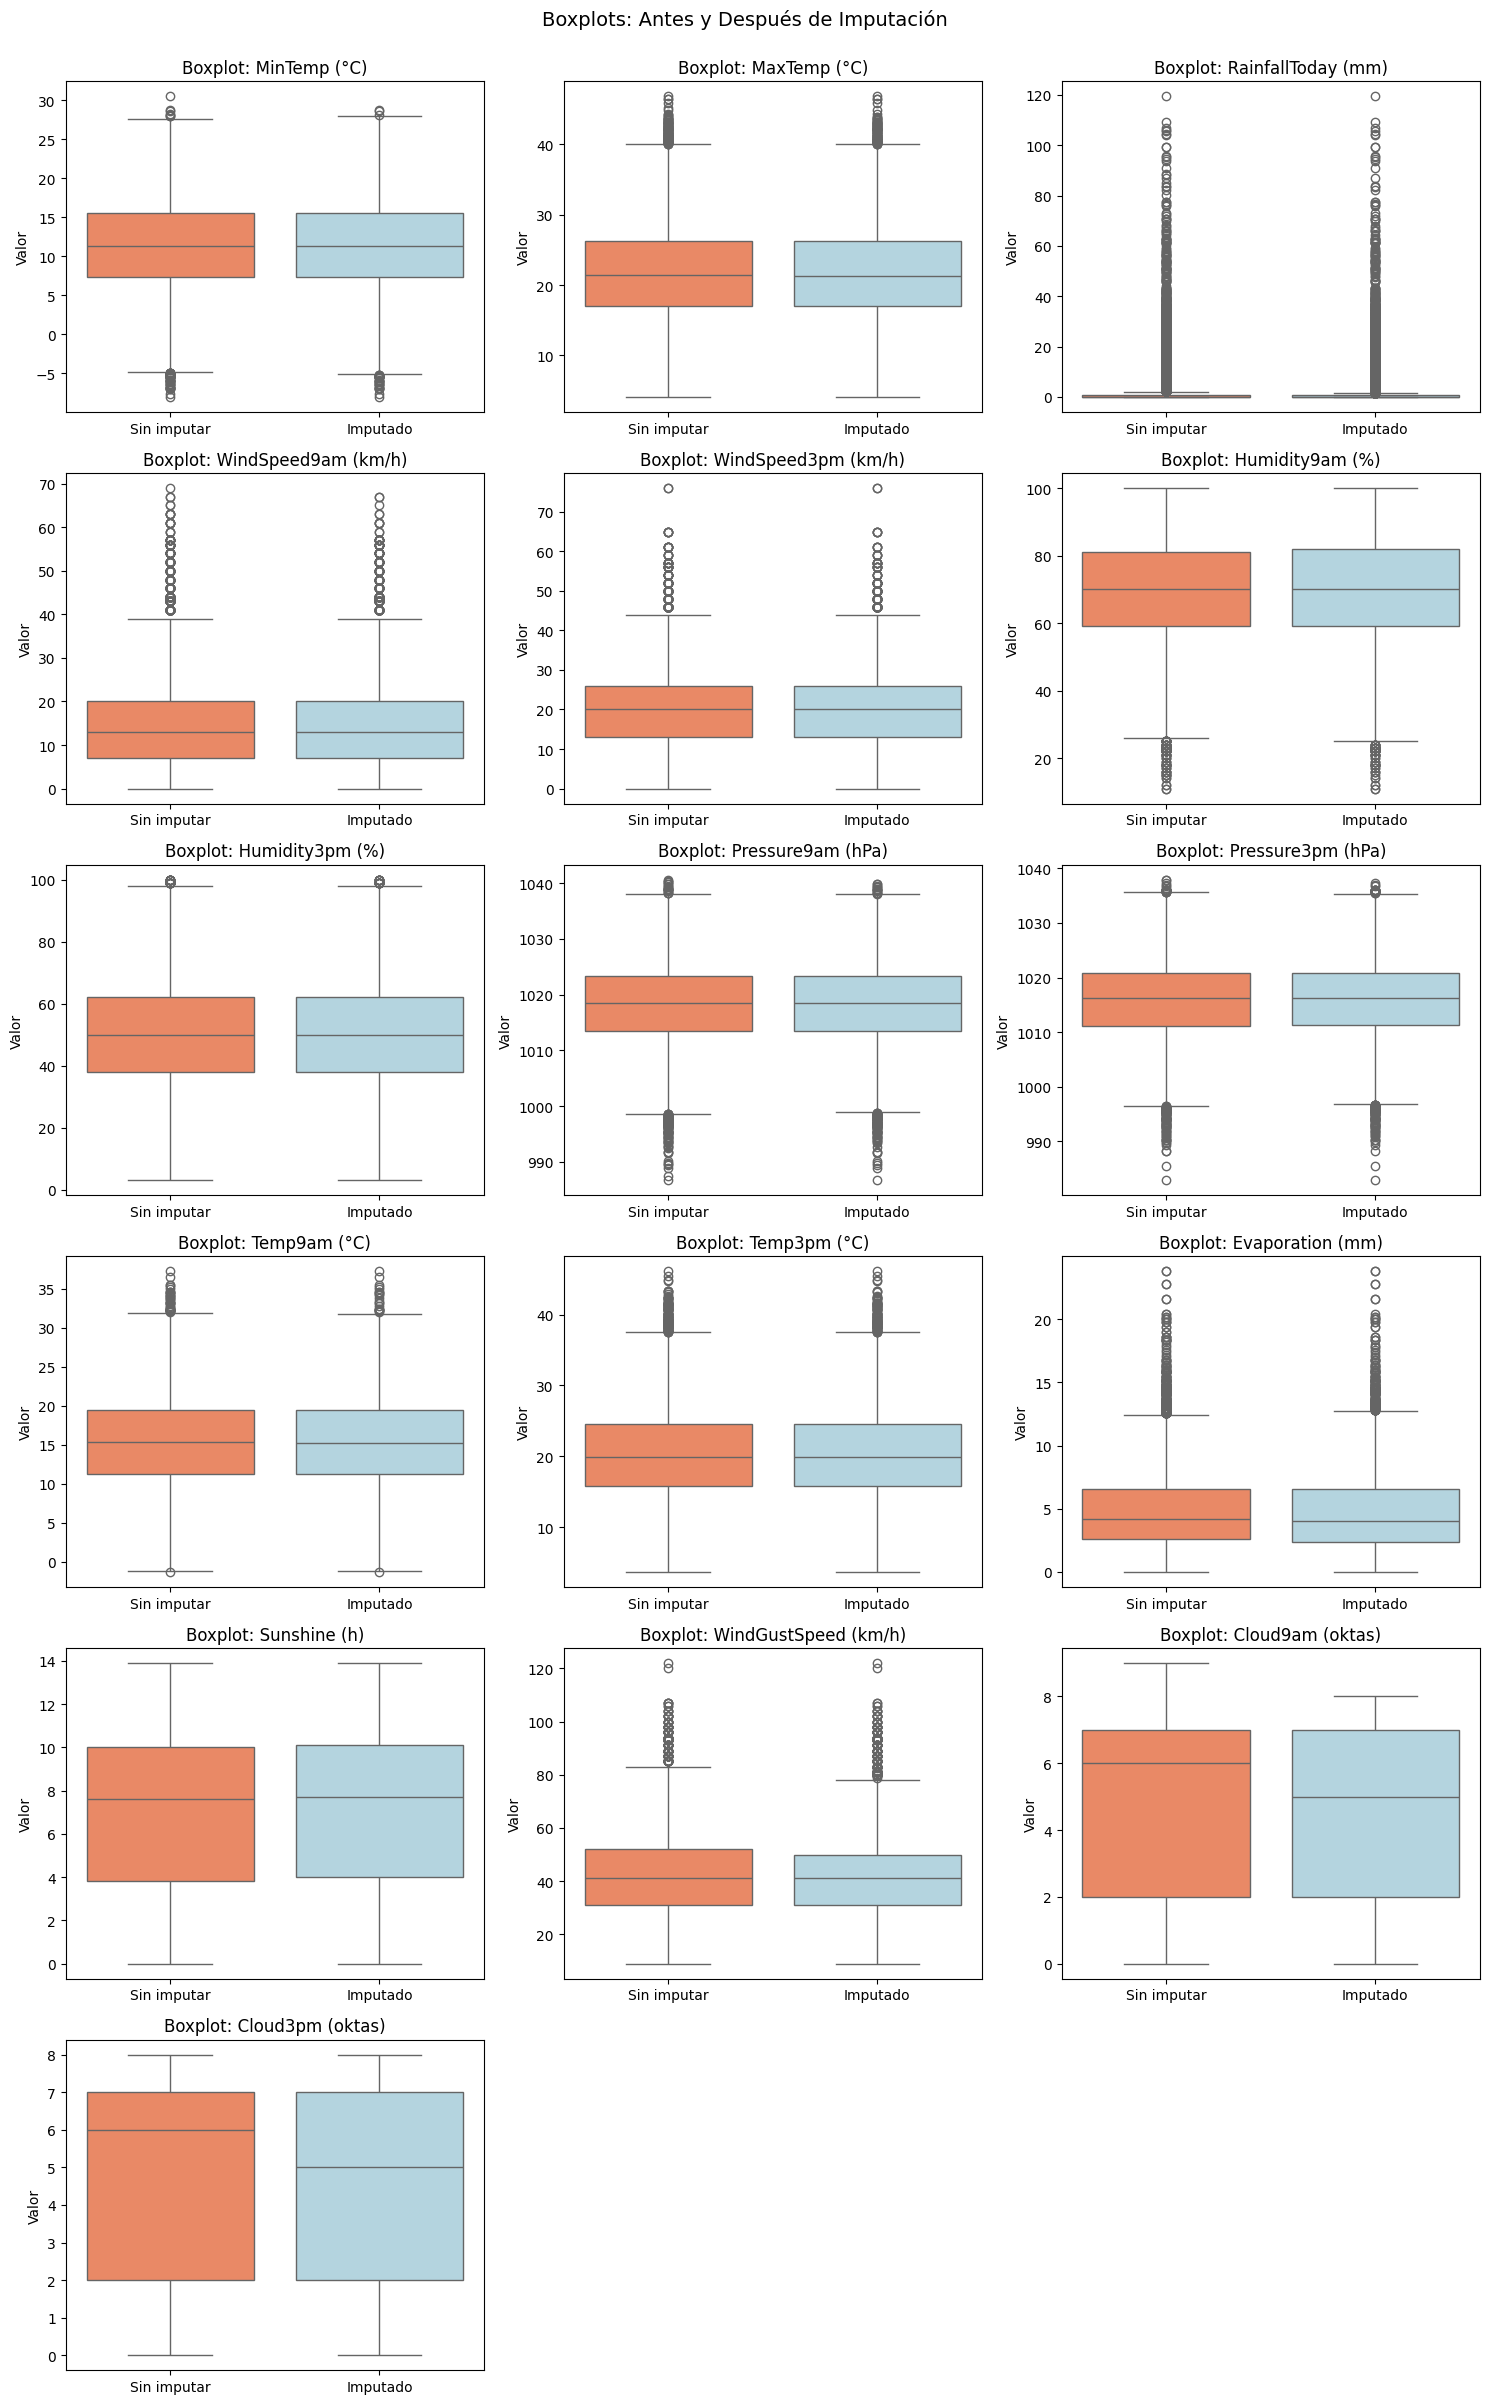

In [120]:
# ---- Boxplots: antes y después de imputación ----
# Los boxplots no se ven afectados por el tamaño del dataset
# ya que muestran mediana, cuartiles y outliers (valores relativos)
# por lo que no requieren normalización
fig, axes = plt.subplots(n_filas_imp, n_cols, figsize=(15, n_filas_imp * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num_imp):
    temp_df = pd.concat([
        pd.DataFrame({col: df[col], 'Estado': 'Sin imputar'}),
        pd.DataFrame({col: X_train[col], 'Estado': 'Imputado'})
    ]).reset_index(drop=True)

    sns.boxplot(data=temp_df, x='Estado', y=col, ax=axes[i],
                palette={'Sin imputar': 'coral', 'Imputado': 'lightblue'},
                hue='Estado', legend=False)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots: Antes y Después de Imputación', fontsize=14, y=1)
plt.tight_layout()
plt.show()

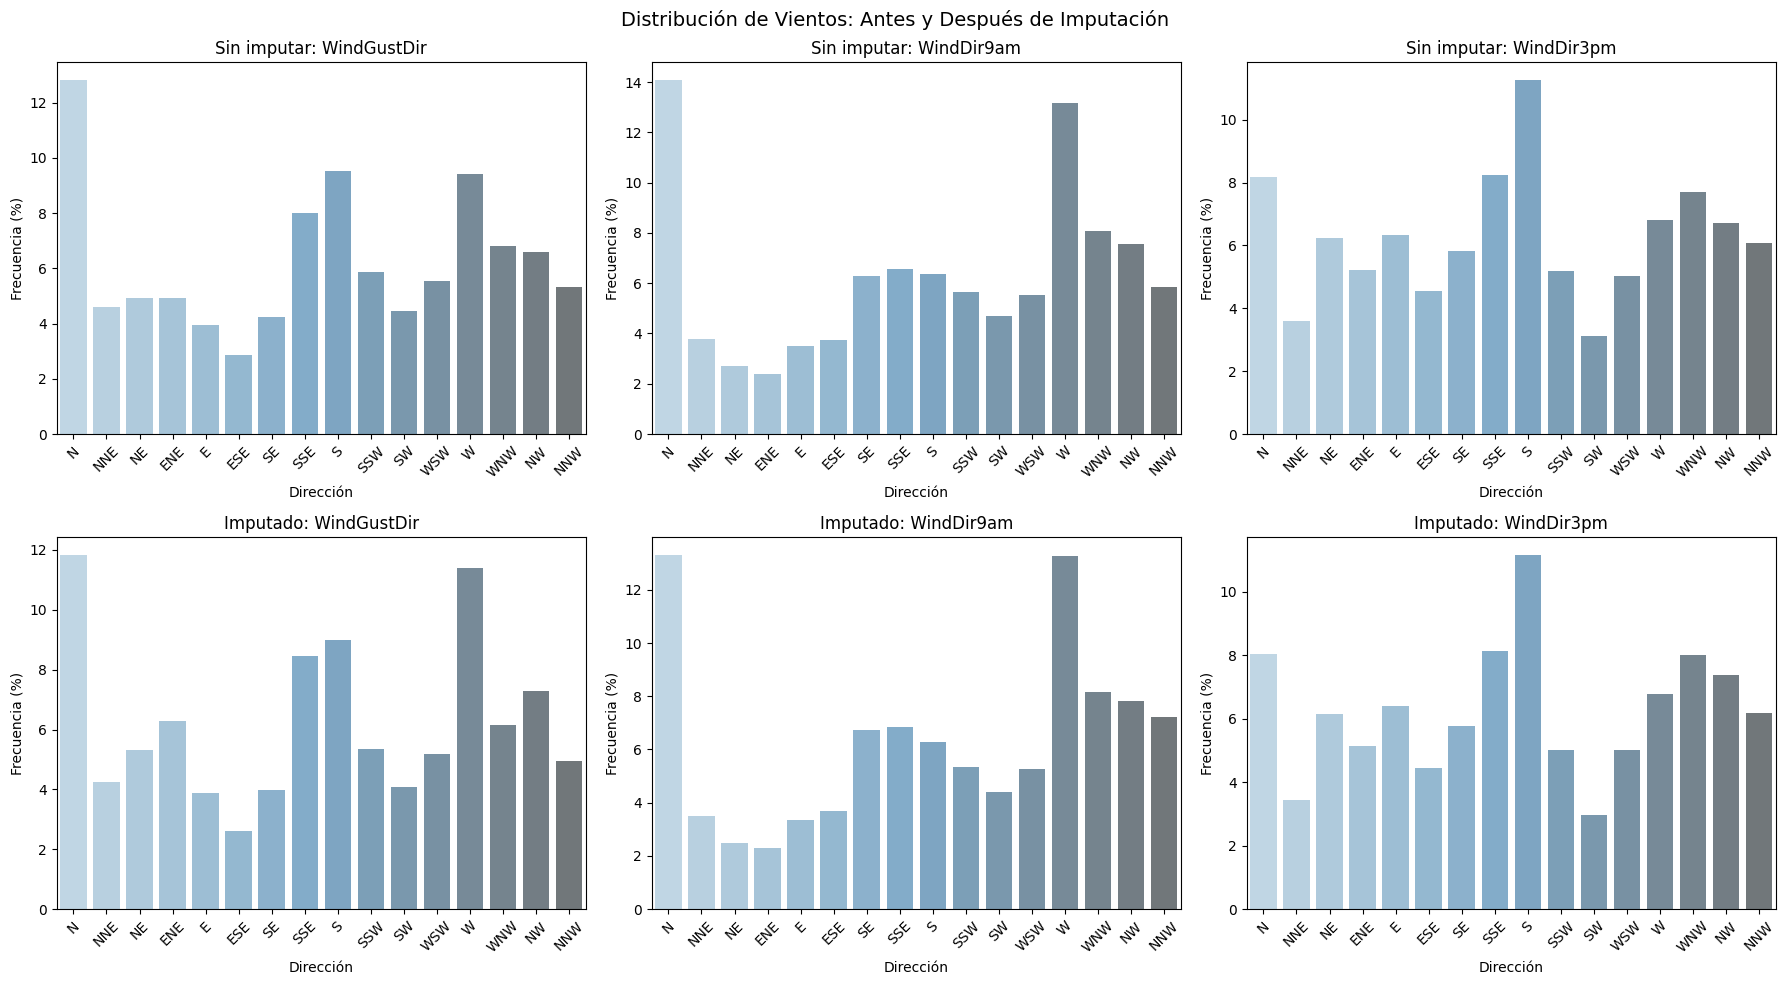

In [121]:
# Frecuencias de viento: antes y después de imputación
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(wind_cols_orig):
    counts_before = df[col].value_counts(normalize=True).reindex(order) * 100
    counts_after  = X_train[col].value_counts(normalize=True).reindex(order) * 100

    # Fila 1: Sin imputar
    sns.barplot(x=counts_before.index, y=counts_before.values, ax=axes[0, i], palette='Blues_d', alpha=0.7)
    axes[0, i].set_title(f'Sin imputar: {col}')
    axes[0, i].set_xlabel('Dirección')
    axes[0, i].set_ylabel('Frecuencia (%)')
    axes[0, i].tick_params(axis='x', rotation=45)

    # Fila 2: Imputado
    sns.barplot(x=counts_after.index, y=counts_after.values, ax=axes[1, i], palette='Blues_d', alpha=0.7)
    axes[1, i].set_title(f'Imputado: {col}')
    axes[1, i].set_xlabel('Dirección')
    axes[1, i].set_ylabel('Frecuencia (%)')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de Vientos: Antes y Después de Imputación', fontsize=14)
plt.tight_layout()
plt.show()

Luego de aplicar la imputación de valores faltantes por mediana por ciudad/mes, KNN para variables con mayor complejidad y moda para categóricas, las comparaciones antes vs. después muestran que la estructura del dataset se conserva de forma adecuada. En los histogramas, las distribuciones permanecen mayormente solapadas; las diferencias más visibles aparecen en Sunshine y en las variables de nubosidad, algo esperable por su alto porcentaje de faltantes. En los boxplots, la mediana y el rango intercuartílico se mantienen muy similares, sin cambios relevantes en la dispersión general. En las frecuencias de direcciones de viento, las proporciones por categoría también se preservan con variaciones menores. En conjunto, estos resultados indican que la imputación no introduce sesgos fuertes y mantiene coherencia estadística con el comportamiento original de los datos.

## Codificación

In [122]:
def transformar_dataset_final(df_imputed):
    df_res = df_imputed.copy()

    # Direcciones de Viento -> Codificación cíclica (Seno y Coseno)
    wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
    for col in wind_cols:
        # Conversión a radianes
        rads = df_res[col].map(wind_dir_map).astype(float) * (np.pi / 180)
        df_res[f'{col}_sin'] = np.sin(rads)
        df_res[f'{col}_cos'] = np.cos(rads)

    # Mes -> Codificaión cíclica (Seno y Coseno - base 12)
    month_rads = df_res['Month'].astype(float) * (2 * np.pi / 12)
    df_res['Month_sin'] = np.sin(month_rads)
    df_res['Month_cos'] = np.cos(month_rads)

    # RainToday -> Mapeo binario
    df_res['RainToday'] = df_res['RainToday'].map({'No': 0, 'Yes': 1})

    # Se eliminan Location y Month
    cols_to_drop = wind_cols + ['Month', 'Location']
    df_res = df_res.drop(columns=cols_to_drop)

    return df_res

# Aplicar la transformación a ambos conjuntos
X_train = transformar_dataset_final(X_train)
X_test = transformar_dataset_final(X_test)

# Target de clasificación -> No: 0 y Si: 1
y_train_class = y_train_class.map({'No': 0, 'Yes': 1})
y_test_class = y_test_class.map({'No': 0, 'Yes': 1})

In [123]:
X_train.head()

,MinTemp (°C),MaxTemp (°C),RainfallToday (mm),Evaporation (mm),Sunshine (h),WindGustSpeed (km/h),WindSpeed9am (km/h),WindSpeed3pm (km/h),Humidity9am (%),Humidity3pm (%),...,Temp3pm (°C),RainToday,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,Month_sin,Month_cos
1802,13.1,31.4,0.0,7.510331,11.358773,20.0,6.0,9.0,53.0,32.0,...,29.9,0,1.224647e-16,-1.000000e+00,0.923880,-0.382683,-0.707107,-0.707107,0.866025,5.000000e-01
1986,3.5,19.1,0.0,2.259836,9.342422,15.0,0.0,9.0,72.0,43.0,...,18.8,0,1.000000e+00,6.123234e-17,0.707107,-0.707107,0.707107,-0.707107,-0.866025,-5.000000e-01
719,13.6,22.6,14.8,4.767297,5.752898,43.0,20.0,22.0,69.0,51.0,...,21.7,1,3.826834e-01,-9.238795e-01,0.707107,-0.707107,0.707107,-0.707107,-0.500000,8.660254e-01
9491,6.4,21.2,0.0,2.800000,7.900000,41.0,9.0,22.0,76.0,41.0,...,21.1,0,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000,1.000000,-1.000000,-1.836970e-16
7034,15.8,27.7,0.0,5.400000,10.500000,26.0,9.0,13.0,69.0,43.0,...,26.7,0,3.826834e-01,-9.238795e-01,0.382683,0.923880,0.707107,-0.707107,1.000000,6.123234e-17


## Escalado

In [124]:
scaler = RobustScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
 )
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
 )

## Análisis de balanceo del dataset

--- Distribución de Clases en Entrenamiento ---
No llueve (0): 11226 muestras (77.08%)
Sí llueve (1): 3338 muestras (22.92%)


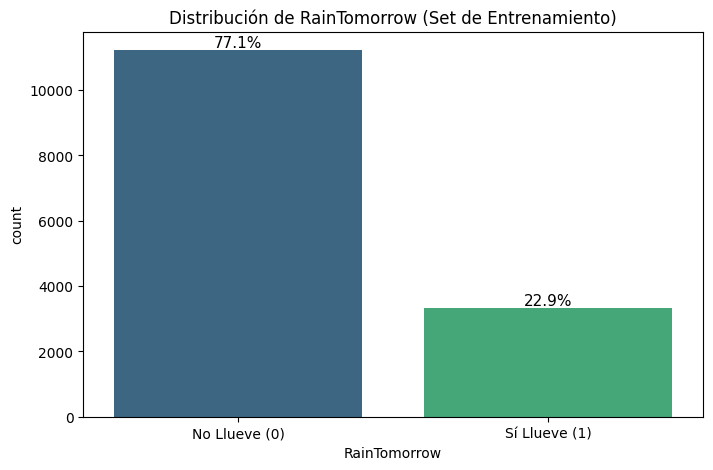

In [125]:
# Suponiendo que y_train_class es tu variable objetivo de entrenamiento
frecuencias = y_train_class.value_counts()
porcentajes = y_train_class.value_counts(normalize=True) * 100

print("--- Distribución de Clases en Entrenamiento ---")
print(f"No llueve (0): {frecuencias[0]} muestras ({porcentajes[0]:.2f}%)")
print(f"Sí llueve (1): {frecuencias[1]} muestras ({porcentajes[1]:.2f}%)")

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y_train_class, palette='viridis')
plt.title('Distribución de RainTomorrow (Set de Entrenamiento)')
plt.xticks(ticks=[0, 1], labels=['No Llueve (0)', 'Sí Llueve (1)'])

# Agregar etiquetas de porcentaje sobre las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{porcentajes[i]:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# **2. Modelo de regresión lineal múltiple**

## LinearRegression

In [126]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train_reg)
y_pred_train = linear_model.predict(X_train)
y_pred_test  = linear_model.predict(X_test)

In [127]:
# Métricas del modelo
rmse_train = root_mean_squared_error(y_train_reg, y_pred_train)
rmse_test  = root_mean_squared_error(y_test_reg,  y_pred_test)

def r2_ajustado(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = n_features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2_train_ajustado = r2_ajustado(y_train_reg, y_pred_train, X_train.shape[1])
r2_test_ajustado = r2_ajustado(y_test_reg, y_pred_test, X_test.shape[1])

print(f"{'Métrica':<10} {'Train':>10} {'Test':>10}")
print(f"{'-'*32}")
print(f"{'RMSE':<10} {rmse_train:>10.2f} {rmse_test:>10.2f}")
print(f"{'R² ajustado':<10} {r2_train_ajustado:>10.2f} {r2_test_ajustado:>10.2f}")

Métrica         Train       Test
--------------------------------
RMSE             6.44       5.80
R² ajustado       0.23       0.25


Se eligieron RMSE y R² ajustado como métricas principales porque son complementarias para evaluar este problema. El RMSE mide el error en milímetros y penaliza más los errores grandes, lo cual es relevante en predicción de lluvia por el impacto de subestimar eventos intensos. El R² ajustado permite medir la capacidad explicativa del modelo corrigiendo por el número de variables, evitando sobreestimar el ajuste por complejidad. 
En los resultados obtenidos (RMSE train = 6.44, test = 5.80; R² ajustado train = 0.23, test = 0.25), la cercanía entre train y test sugiere que no hay sobreajuste significativo y que el modelo generaliza de forma estable. Sin embargo, el R² ajustado bajo indica que la regresión lineal solo explica una parte limitada de la variabilidad de la lluvia, por lo que persiste underfitting.


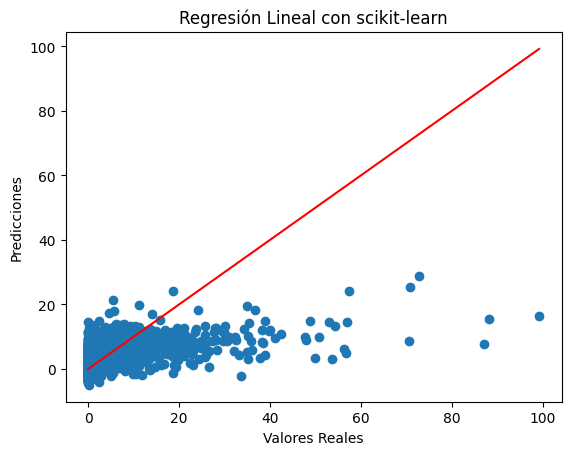

In [128]:
plt.scatter(y_test_reg, y_pred_test)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red')
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal con scikit-learn")
plt.show()

El modelo lineal no sigue bien la diagonal ideal: las predicciones quedan comprimidas en valores bajos, con subestimación de eventos de lluvia intensa. Esto evidencia underfitting y limitada capacidad para modelar la variabilidad real de la lluvia.

In [129]:
def resPlot(modelo, nombre_modelo, x_test, y_test):
    pred = modelo.predict(x_test)

    if hasattr(y_test, 'values'):
        y_test_array = y_test.values.ravel()
    else:
        y_test_array = y_test.ravel()

    pred = pred.ravel()

    plt.figure(figsize=(5,3))
    plt.scatter(pred, y_test_array - pred, s=6, alpha=0.6)
    plt.axhline(0, color='k')
    plt.title(f"Residuos - {nombre_modelo}")
    plt.xlabel("Predicho")
    plt.ylabel("Residuo")
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(8,4))
    fig.suptitle(f'Residuos porcentuales - {nombre_modelo}')
    plt.xlabel('Valores de test')
    plt.ylabel('Residuos (%)')

    percentage_residuals = np.where(y_test_array != 0,
                                   100 * (y_test_array - pred) / y_test_array, 0)
    plt.scatter(y_test_array, percentage_residuals, s=6, alpha=0.6)
    plt.axhline(0, color='k')
    plt.show()

    return

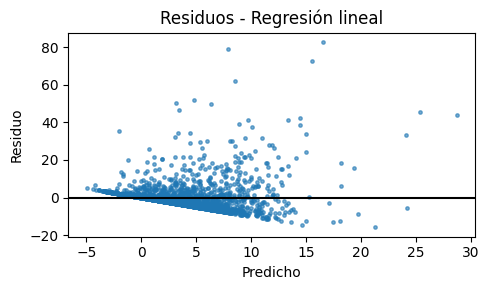

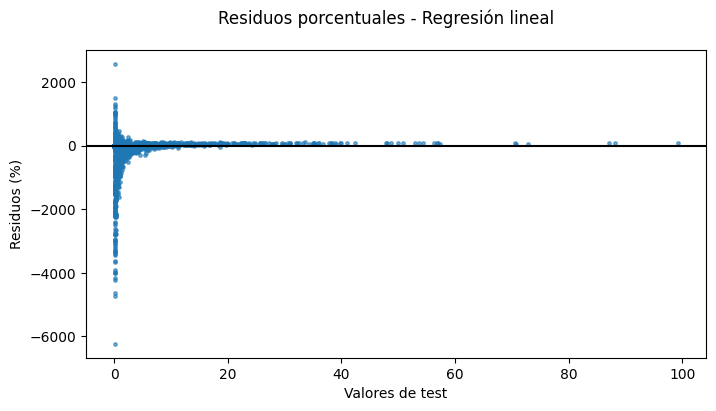

In [130]:
resPlot(linear_model, 'Regresión lineal', X_test, y_test_reg)

El gráfico de residuos indica que el error aumenta a medida que aumentan las predicciones. Los residuos no están distribuidos aleatoriamente alrededor del cero.
El gráfico de residuos porcentuales indica que para valores mayores a 20 mm los residuos se estabilizan, lo que sugiere que el modelo funciona relativamente mejor en días con lluvia moderada-alta que en días sin lluvia o con lluvia mínima.

Text(0, 0.5, 'Frecuencia')

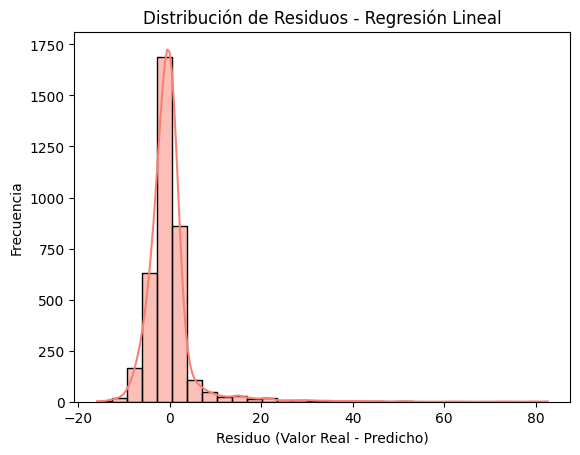

In [131]:
sns.histplot(y_test_reg - y_pred_test, kde=True, color='salmon', bins=30)
plt.title('Distribución de Residuos - Regresión Lineal')
plt.xlabel('Residuo (Valor Real - Predicho)')
plt.ylabel('Frecuencia')

Los tres gráficos muestran un patrón similar, donde la variable de lluvia está fuertemente sesgada hacia valores bajos/cercanos a cero, con una cola larga de eventos intensos. Por eso, la regresión lineal presenta residuos no homogéneos y errores porcentuales extremos cuando el valor real es muy chico. En síntesis, la distribución es razonable para un fenómeno meteorológico, pero no ideal para un modelo lineal simple sin transformaciones.

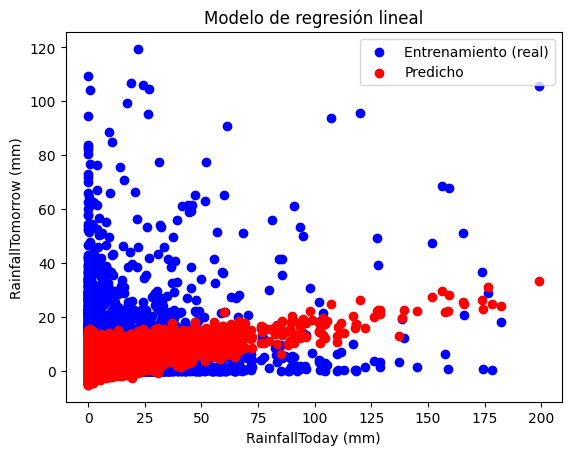

In [132]:
plt.scatter(X_train['RainfallToday (mm)'], y_train_reg, color='blue',label='Entrenamiento (real)')
plt.scatter(X_train['RainfallToday (mm)'], linear_model.predict(X_train), color='red',label='Predicho')

plt.xlabel('RainfallToday (mm)')
plt.ylabel('RainfallTomorrow (mm)')
plt.legend()
plt.title('Modelo de regresión lineal')

plt.show()

El gráfico muestra que para un mismo valor de RainfallToday, la lluvia del día siguiente puede variar mucho, evidenciando que la relación entre ambas variables no es lineal. Las predicciones del modelo predicho indica que está prediciendo la media de la lluvia en lugar de capturar la variabilidad real. Esto confirma visualmente el underfitting detectado en las métricas, que una relación lineal no es suficiente para representar la complejidad del fenómeno meteorológico.

## Gradiente descendiente

In [133]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, tol=1e-6, patience=10):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_val = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]
    o = X_val.shape[0]

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # Inicializar pesos aleatorios
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        # Predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train

        # Gradiente y actualización (una actualización = una iteración en GD)
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2 / n * grad_sum
        gradient = np.transpose(grad_mul).reshape(-1, 1)
        W = W - (lr * gradient)

        # Registrar errores luego de la actualización
        prediction_train = np.matmul(X_train, W)
        prediction_test = np.matmul(X_val, W)
        train_errors.append(np.mean((y_train - prediction_train) ** 2))
        test_errors.append(np.mean((y_val - prediction_test) ** 2))

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (GD)')
    plt.show()

    return W


def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, tol=1e-6, patience=10):
    n = X_train.shape[0]
    m = X_train.shape[1]

    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(n):
            x_sample = X_train_shuffled[j].reshape(-1, 1)
            y_scalar = y_train_shuffled[j, 0]

            y_pred_scalar = float((x_sample.T @ W).item())
            error_scalar = y_scalar - y_pred_scalar

            gradient = (-2.0 * error_scalar) * x_sample
            W = W - (lr * gradient)

            # Registrar errores globales en cada actualización (iteración)
            prediction_train = X_train @ W
            prediction_test = X_test @ W
            train_errors.append(np.mean((y_train - prediction_train) ** 2))
            test_errors.append(np.mean((y_test - prediction_test) ** 2))

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=32, tol=1e-6, patience=10):
    n = X_train.shape[0]
    m = X_train.shape[1]

    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train_shuffled[j:j + batch_size, :]
            y_batch = y_train_shuffled[j:j + batch_size, :]

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction

            gradient = -2 * np.matmul(x_batch.T, error) / x_batch.shape[0]
            W = W - (lr * gradient)

            # Registrar errores globales en cada actualización (iteración)
            prediction_train = np.matmul(X_train, W)
            prediction_test = np.matmul(X_test, W)
            train_errors.append(np.mean((y_train - prediction_train) ** 2))
            test_errors.append(np.mean((y_test - prediction_test) ** 2))

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

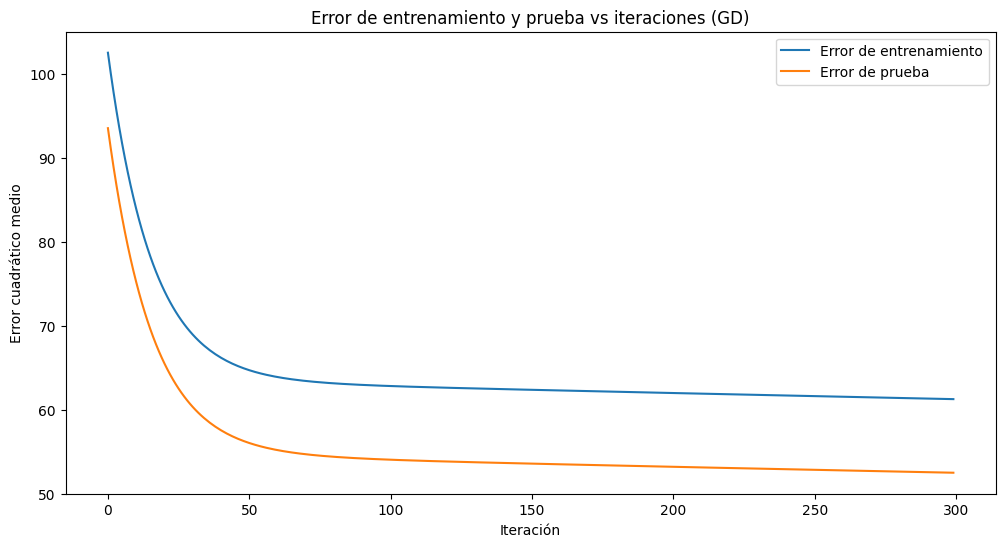

array([[-0.11409126],
       [ 0.94510752],
       [-0.28295552],
       [ 0.24599843],
       [-1.45324967],
       [-0.40177857],
       [ 0.3111848 ],
       [ 1.4132289 ],
       [ 0.04542238],
       [-0.12360347],
       [ 0.13160467],
       [ 1.19775843],
       [ 1.20534459],
       [-1.22031207],
       [-1.02619839],
       [ 0.79096985],
       [ 0.81039479],
       [-1.68927902],
       [ 0.92841133],
       [-0.04931021],
       [ 0.89566691],
       [-0.26535416],
       [-0.35099035],
       [-0.98678071],
       [-0.25837381],
       [-1.57172685]])

In [134]:
gradient_descent(X_train.values,
    y_train_reg.values,
    X_test.values,
    y_test_reg.values,
    lr=0.00010,
    epochs=300
)

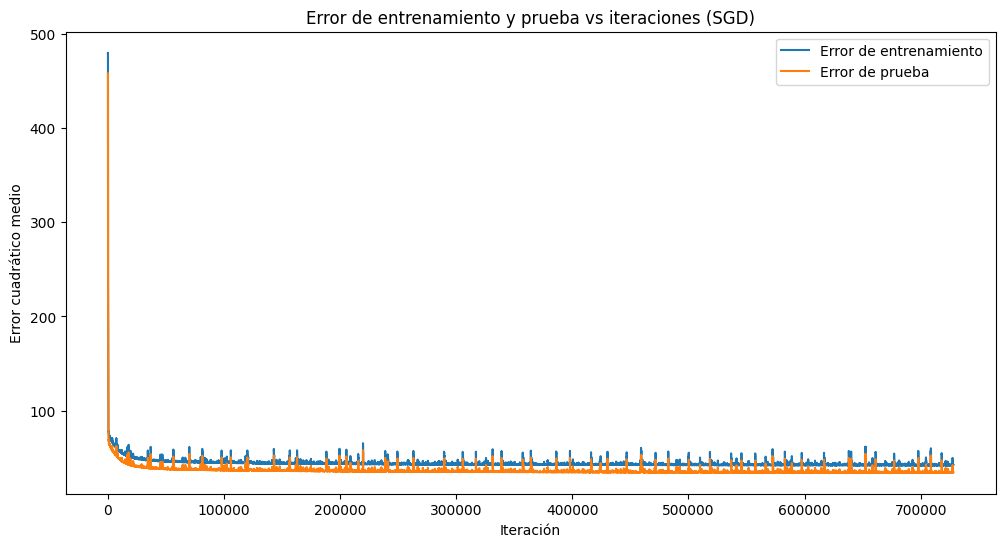

array([[ 1.48280577],
       [-0.78408797],
       [ 1.26225883],
       [ 0.05094572],
       [ 0.02150193],
       [-1.58578964],
       [ 1.98016451],
       [-0.15997662],
       [-0.86687669],
       [ 0.151799  ],
       [ 2.68269352],
       [ 0.42121216],
       [-0.94952589],
       [-0.5402562 ],
       [ 0.48603269],
       [ 0.78529257],
       [ 0.04916685],
       [-0.18871143],
       [ 0.17182468],
       [-0.26576241],
       [ 0.48706041],
       [-0.55642877],
       [ 0.38577632],
       [ 0.13560389],
       [-0.1781645 ],
       [-0.6130149 ]])

In [135]:
stochastic_gradient_descent(X_train.values, y_train_reg.values, X_test.values, y_test_reg.values, lr=1e-5, epochs=50)

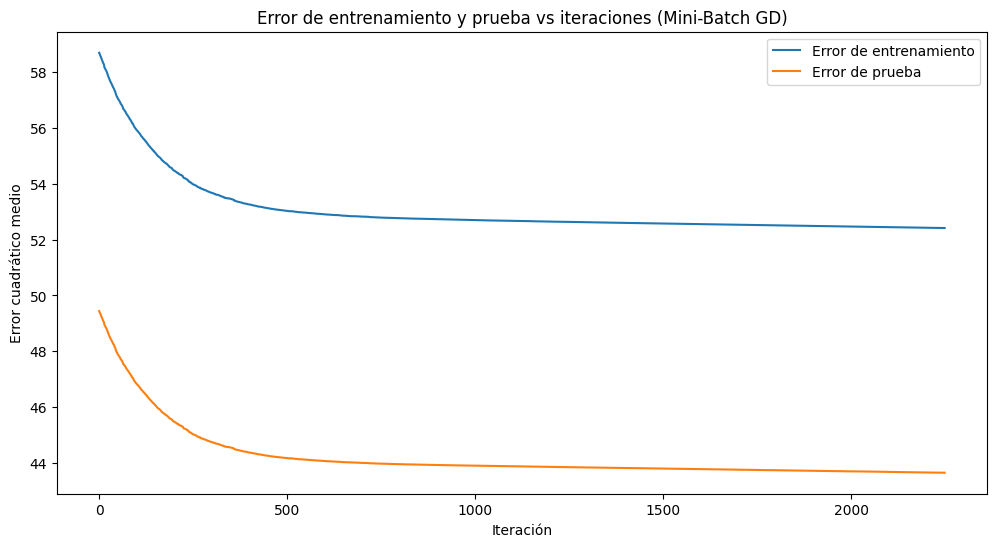

array([[ 0.39575773],
       [-0.72538031],
       [-0.69463487],
       [ 0.17791917],
       [ 0.73462288],
       [-0.20268377],
       [ 1.75129502],
       [ 0.48111807],
       [-1.47236871],
       [ 0.43727999],
       [-0.77097737],
       [-0.56478564],
       [ 0.79117278],
       [ 2.27066274],
       [ 1.03212739],
       [ 0.71346606],
       [ 0.16927791],
       [-0.46184171],
       [ 0.00905475],
       [ 1.1234673 ],
       [-0.97971256],
       [-0.7469332 ],
       [ 0.42875361],
       [-0.28238125],
       [ 1.8093123 ],
       [-0.34596759]])

In [136]:
mini_batch_gradient_descent(X_train.values, y_train_reg.values, X_test.values, y_test_reg.values, lr=0.00001, epochs=150, batch_size=1024)

En las corridas por iteración, el GD clásico muestra una convergencia suave y estable, ambas curvas descienden rápido al inicio y luego se aplanan, quedando aproximadamente en MSE de entrenamiento cercano a 60 y de prueba cercano a 53, sin señales de inestabilidad. El SGD, en cambio, presenta la mayor variabilidad, dado que aunque su tendencia general también es descendente y alcanza errores medios más bajos, aparecen picos frecuentes en ambas curvas por la actualización muestra a muestra, lo que confirma su alta sensibilidad al ruido y a outliers. El Mini-Batch GD se comporta como un punto intermedio, con una convergencia casi tan estable como GD pero más rápida en cantidad de actualizaciones, y con curvas bastante más suaves que SGD. En los tres métodos, la curva de prueba se mantiene por debajo de la de entrenamiento durante casi todo el proceso, por lo que no se observan indicios de overfitting en esta etapa.


## Regularización

In [137]:
alpha_val = 0.1

lasso = Lasso(alpha=alpha_val)
ridge = Ridge(alpha=alpha_val)
elasticnet = ElasticNet(alpha=alpha_val, l1_ratio=0.5)

lasso.fit(X_train, y_train_reg)
ridge.fit(X_train, y_train_reg)
elasticnet.fit(X_train, y_train_reg)

# Métricas
for nombre, modelo in [('Lasso', lasso), ('Ridge', ridge), ('ElasticNet', elasticnet)]:
    pred = modelo.predict(X_test)
    rmse = root_mean_squared_error(y_test_reg, pred)
    r2_adj = r2_ajustado(y_test_reg, pred, X_test.shape[1])
    print(f"{nombre} → RMSE: {rmse:.4f} | R² ajustado: {r2_adj:.4f}")

Lasso → RMSE: 5.8918 | R² ajustado: 0.2263
Ridge → RMSE: 5.8027 | R² ajustado: 0.2496
ElasticNet → RMSE: 5.8866 | R² ajustado: 0.2277


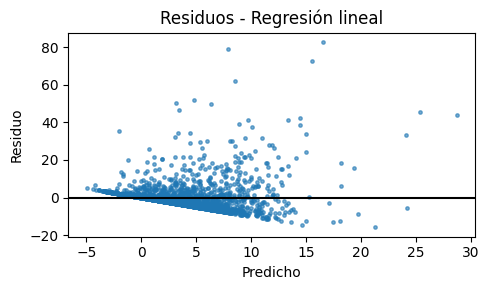

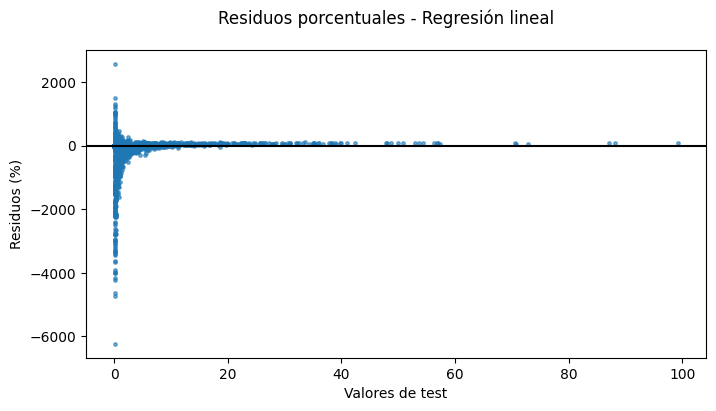

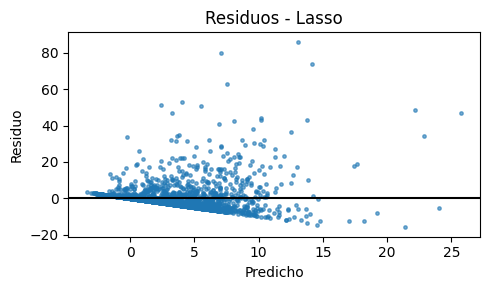

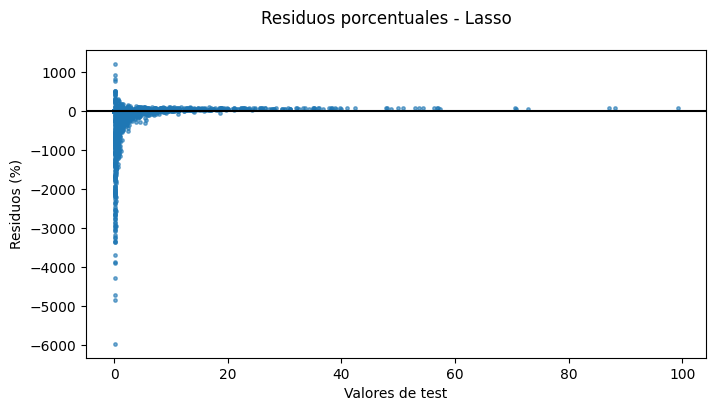

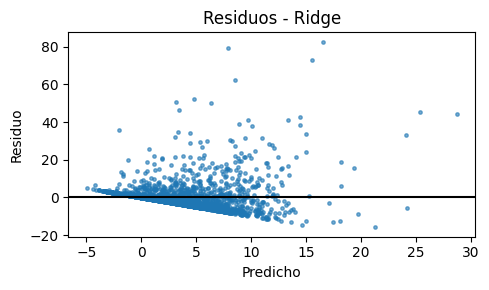

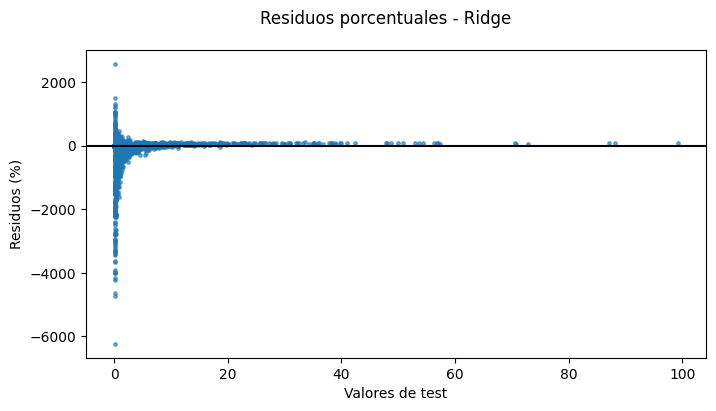

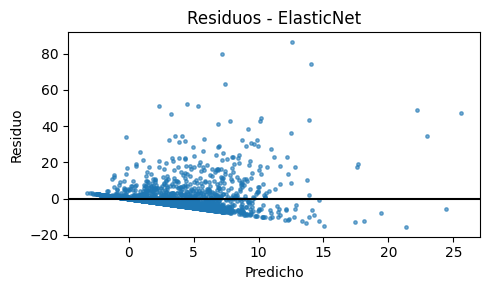

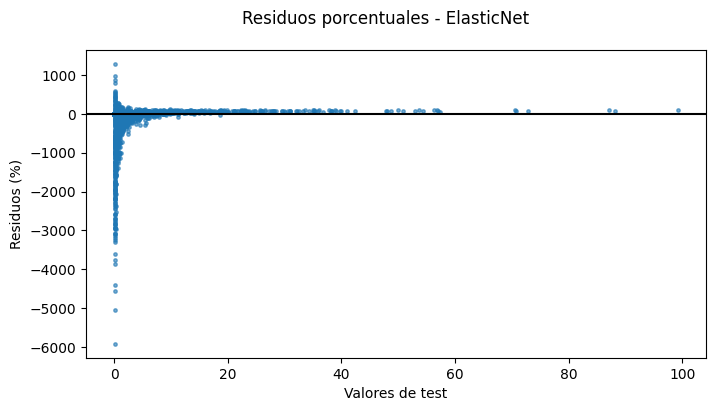

In [138]:
resPlot(linear_model, 'Regresión lineal', X_test, y_test_reg)
resPlot(lasso, 'Lasso', X_test, y_test_reg)
resPlot(ridge, 'Ridge', X_test, y_test_reg)
resPlot(elasticnet, 'ElasticNet', X_test, y_test_reg)

La regularización no produjo una mejora relevante respecto de la regresión lineal base. Aunque Ridge obtuvo el mejor resultado (RMSE 5.80 y R2 ajustado 0.25), la diferencia frente a Lasso y ElasticNet es marginal, y los gráficos de residuos se mantienen prácticamente idénticos. Esto sugiere que el problema principal no era el sobreajuste, sino la limitada capacidad de los modelos lineales para capturar la no linealidad lluvia, por lo que persiste underfitting.

# **3. Modelo de clasificación binaria**

## LogisticRegression con class_weight='balanced'

In [139]:
# Modelo con pesos balanceados
model_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_balanced.fit(X_train, y_train_class)

# Predicción
y_pred_bal = model_balanced.predict(X_test)

print("\n--- Reporte de Clasificación: Pesos Balanceados ---")
print(classification_report(y_test_class, y_pred_bal))


--- Reporte de Clasificación: Pesos Balanceados ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      2807
           1       0.52      0.77      0.62       835

    accuracy                           0.78      3642
   macro avg       0.72      0.78      0.74      3642
weighted avg       0.83      0.78      0.80      3642



## LogisticRegression con SMOTE

In [140]:
# 1. Aplicar SMOTE únicamente al set de ENTRENAMIENTO
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train_class)

print(f"\nDistribución original: {Counter(y_train_class)}")
print(f"Distribución tras SMOTE: {Counter(y_train_smote)}")

# 2. Entrenar una Regresión Logística estándar sobre los datos aumentados
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# 3. Predicción (siempre sobre el X_test original)
y_pred_smote = model_smote.predict(X_test)

print("\n--- Reporte de Clasificación: SMOTE ---")
print(classification_report(y_test_class, y_pred_smote))


Distribución original: Counter({0: 11226, 1: 3338})
Distribución tras SMOTE: Counter({0: 11226, 1: 11226})

--- Reporte de Clasificación: SMOTE ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      2807
           1       0.52      0.77      0.62       835

    accuracy                           0.78      3642
   macro avg       0.72      0.78      0.73      3642
weighted avg       0.83      0.78      0.80      3642



## Comparación de métodos de balanceo

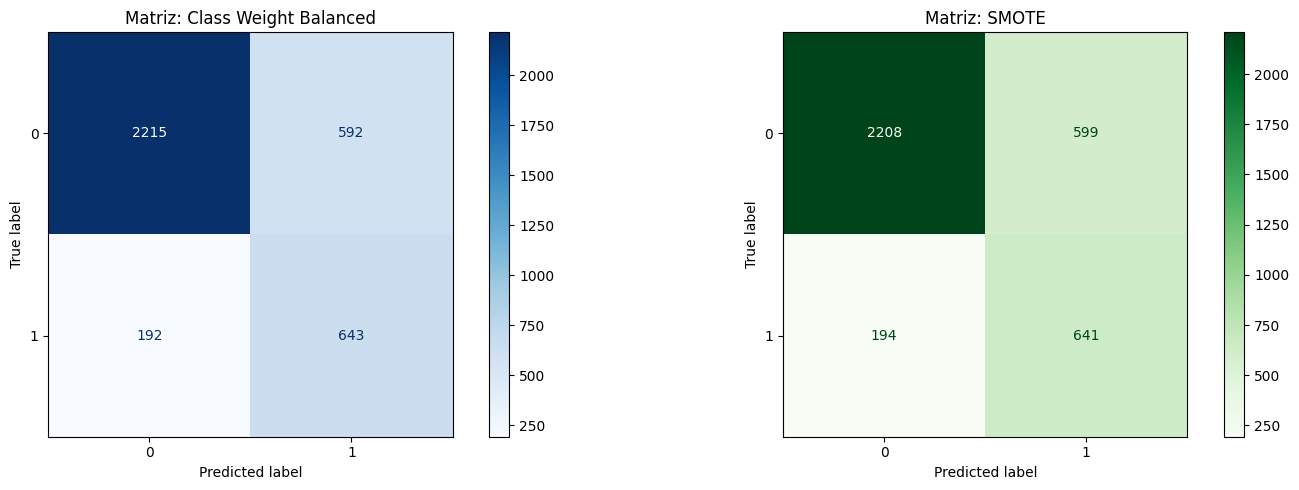

In [141]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz para Pesos Balanceados
ConfusionMatrixDisplay.from_predictions(y_test_class, y_pred_bal,
                                        cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz: Class Weight Balanced')

# Matriz para SMOTE
ConfusionMatrixDisplay.from_predictions(y_test_class, y_pred_smote,
                                        cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz: SMOTE')

plt.tight_layout()
plt.show()

Ambos métodos de balanceo obtienen resultados muy parecidos tanto en métricas como en las matrices de confusión. Se prefiere seguir con SMOTE dado que al generar ejemplos interpolando entre instancias reales puede favorecer una mejor generalización en modelos más complejos aplicados posteriormente.

## Curvas ROC

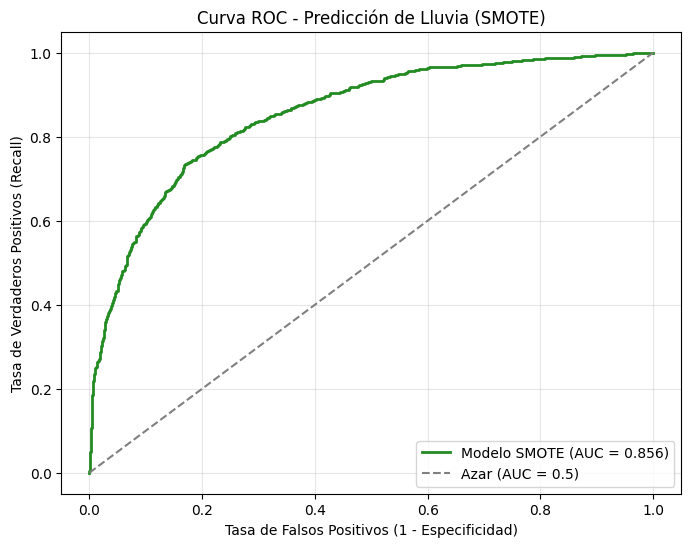

In [142]:
# Probabilidades de la clase positiva (1: Sí llueve)
y_probs_smote = model_smote.predict_proba(X_test)[:, 1]

# FPR, TPR y Umbrales para la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test_class, y_probs_smote)
auc_val = roc_auc_score(y_test_class, y_probs_smote)

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='forestgreen', lw=2, label=f'Modelo SMOTE (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (AUC = 0.5)')
plt.title('Curva ROC - Predicción de Lluvia (SMOTE)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [143]:
# Predicciones para ambos conjuntos
y_pred_train = model_smote.predict(X_train_smote) # Datos balanceados
y_pred_test = model_smote.predict(X_test)

print("--- REPORTE ENTRENAMIENTO (SMOTE) ---")
print(classification_report(y_train_smote, y_pred_train))

print("\n--- REPORTE TEST (REAL) ---")
print(classification_report(y_test_class, y_pred_test))

--- REPORTE ENTRENAMIENTO (SMOTE) ---
              precision    recall  f1-score   support

           0       0.78      0.79      0.79     11226
           1       0.79      0.77      0.78     11226

    accuracy                           0.78     22452
   macro avg       0.78      0.78      0.78     22452
weighted avg       0.78      0.78      0.78     22452


--- REPORTE TEST (REAL) ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      2807
           1       0.52      0.77      0.62       835

    accuracy                           0.78      3642
   macro avg       0.72      0.78      0.73      3642
weighted avg       0.83      0.78      0.80      3642



In [144]:
# OPTIMIZACIÓN DE UMBRAL CON CONJUNTO DE VALIDACIÓN
print("\n" + "="*60)
print("OPTIMIZANDO UMBRAL EN CONJUNTO DE VALIDACIÓN")
print("="*60)

# Split interno de entrenamiento/validación (solo para elegir umbral)
X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_train, y_train_class,
    test_size=0.2,
    random_state=42,
    stratify=y_train_class
)

# Entrenar modelo en train interno balanceado con SMOTE
sm_val = SMOTE(random_state=42)
X_train_cls_smote, y_train_cls_smote = sm_val.fit_resample(X_train_cls, y_train_cls)

model_smote_val = LogisticRegression(random_state=42, max_iter=1000)
model_smote_val.fit(X_train_cls_smote, y_train_cls_smote)

# Probabilidades en VALIDACIÓN y búsqueda de umbral por F1
y_proba_valid = model_smote_val.predict_proba(X_val_cls)[:, 1]
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_val_cls, y_proba_valid)

f1_scores_valid = []
for thresh in thresholds_valid:
    y_pred_thresh = (y_proba_valid >= thresh).astype(int)
    f1_scores_valid.append(f1_score(y_val_cls, y_pred_thresh))

optimal_idx = np.argmax(f1_scores_valid)
optimal_threshold = thresholds_valid[optimal_idx]
best_f1_valid = f1_scores_valid[optimal_idx]

print(f"\nÓptimo umbral (maximizando F1 en validación): {optimal_threshold:.4f}")
print(f"F1-score en validación con umbral óptimo: {best_f1_valid:.4f}")

# 4) Entrenar modelo final en TODO el train (balanceado) y evaluar en test
sm_full = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm_full.fit_resample(X_train, y_train_class)

model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

print("\n" + "="*60)
print("EVALUACIÓN EN CONJUNTO DE TEST FINAL")
print("="*60)

y_proba_test = model_smote.predict_proba(X_test)[:, 1]
y_pred_optimal_test = (y_proba_test >= optimal_threshold).astype(int)
y_pred_05_test = (y_proba_test >= 0.5).astype(int)

print(f"\nMétricas en TEST con umbral 0.5:")
print(f"  F1-score: {f1_score(y_test_class, y_pred_05_test):.4f}")
print(f"  Accuracy: {accuracy_score(y_test_class, y_pred_05_test):.4f}")
print(f"  Precision: {precision_score(y_test_class, y_pred_05_test):.4f}")
print(f"  Recall: {recall_score(y_test_class, y_pred_05_test):.4f}")

print(f"\nMétricas en TEST con umbral óptimo ({optimal_threshold:.4f}):")
print(f"  F1-score: {f1_score(y_test_class, y_pred_optimal_test):.4f}")
print(f"  Accuracy: {accuracy_score(y_test_class, y_pred_optimal_test):.4f}")
print(f"  Precision: {precision_score(y_test_class, y_pred_optimal_test):.4f}")
print(f"  Recall: {recall_score(y_test_class, y_pred_optimal_test):.4f}")


OPTIMIZANDO UMBRAL EN CONJUNTO DE VALIDACIÓN

Óptimo umbral (maximizando F1 en validación): 0.5854
F1-score en validación con umbral óptimo: 0.6323

EVALUACIÓN EN CONJUNTO DE TEST FINAL

Métricas en TEST con umbral 0.5:
  F1-score: 0.6178
  Accuracy: 0.7823
  Precision: 0.5169
  Recall: 0.7677

Métricas en TEST con umbral óptimo (0.5854):
  F1-score: 0.6295
  Accuracy: 0.8103
  Precision: 0.5699
  Recall: 0.7030


Con un AUC de 0.856, la regresión logística con SMOTE muestra buena capacidad para discriminar entre días lluviosos y no lluviosos, claramente por encima del clasificador aleatorio.

Para seleccionar el umbral de decisión se utilizó un conjunto de validación tomado desde entrenamiento, maximizando F1 en ese conjunto y evitando ajustar el umbral directamente con test. Luego, con ese umbral fijo, se evaluó el modelo en test final y se comparó contra el umbral estándar 0.5.

En términos prácticos, un umbral más bajo prioriza recall (detectar más días con lluvia, a costa de más falsas alarmas), mientras que un umbral más alto prioriza precision (menos falsas alarmas, a costa de omitir algunos eventos). En un contexto meteorológico, el umbral elegido debe alinearse con el costo relativo entre falsas alarmas y lluvias no detectadas.

# **4. Red neuronal**

## Regresión

In [145]:
# Split de validación para la red neuronal de regresión
X_train_nn_reg, X_val_nn_reg, y_train_nn_reg, y_val_nn_reg = train_test_split(
    X_train,
    y_train_reg,
    test_size=0.2,
    random_state=42
)

print('Regresión NN - tamaños:')
print(f'  Train: {X_train_nn_reg.shape}, {y_train_nn_reg.shape}')
print(f'  Validación: {X_val_nn_reg.shape}, {y_val_nn_reg.shape}')

Regresión NN - tamaños:
  Train: (11651, 25), (11651,)
  Validación: (2913, 25), (2913,)


In [166]:
class RedNeuronalRegresora:
    def __init__(self, épocas=100, batch_size=32, learning_rate=0.001, dropout_rate=0.2):
        self.épocas = épocas
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.model = None

    def build_model(self, input_shape):
        # Arquitectura: 2 capas ocultas con Dropout para evitar overfitting
        model = models.Sequential([
            layers.Input(shape=(input_shape,)),
            layers.Dense(64, activation='relu'),
            layers.Dropout(self.dropout_rate),
            layers.Dense(32, activation='relu'),
            layers.Dropout(self.dropout_rate),
            # Capa de salida: 1 neurona con activación lineal (o relu si la lluvia no puede ser < 0)
            layers.Dense(1, activation='relu')
        ])

        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        # Compilación para regresión: loss='mse'
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        from tensorflow.keras.callbacks import EarlyStopping

        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        # Entrenamiento
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.épocas,
            batch_size=self.batch_size,
            callbacks=[early_stopping],
            verbose=1
        )
        return history.history['loss'], history.history['val_loss']

    def evaluate(self, X_test, y_test):
        y_pred = self.model.predict(X_test).flatten()
        rmse = root_mean_squared_error(y_test, y_pred)
        r2_adj = r2_ajustado(y_test, y_pred, X_test.shape[1])

        print(f"\n--- MÉTRICAS RED NEURONAL (Regresión) ---")
        print(f"Test RMSE: {rmse:.4f}")
        print(f"Test R² ajustado: {r2_adj:.4f}")

    def predict(self, X_new):
        return self.model.predict(X_new)

La red de regresión usa dos capas ocultas (64 y 32 neuronas) con activación ReLU y Dropout para reducir overfitting. La salida tiene 1 neurona (predicción de mm de lluvia), se entrena con Adam y pérdida MSE, y durante el entrenamiento se aplica EarlyStopping sobre `val_loss` para conservar los mejores pesos.

In [167]:
# Instancia la red con hiperparámetros
nn_regresion = RedNeuronalRegresora(épocas=100, batch_size=64, learning_rate=0.001)

# Construye el modelo basado en la cantidad de columnas de X de entrenamiento
nn_regresion.build_model(input_shape=X_train_nn_reg.shape[1])

# Entrenamiento con validación
history_loss, history_val_loss = nn_regresion.train(
    X_train_nn_reg, y_train_nn_reg,
    X_val_nn_reg, y_val_nn_reg
)

# Evalua en el conjunto de Test
nn_regresion.evaluate(X_test, y_test_reg)

Epoch 1/100


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 48.9758 - mae: 2.7090 - val_loss: 44.4767 - val_mae: 2.6873
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43.6599 - mae: 2.6627 - val_loss: 42.0126 - val_mae: 2.6175
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.9991 - mae: 2.4736 - val_loss: 40.9082 - val_mae: 2.4075
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - loss: 41.2823 - mae: 2.3831 - val_loss: 39.9167 - val_mae: 2.4665
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 40.4980 - mae: 2.3785 - val_loss: 39.7890 - val_mae: 2.3247
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39.6293 - mae: 2.3470 - val_loss: 39.4121 - val_mae: 2.3639
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.8195 - mae: 2.3390 - val_loss: 39.4976 - val_mae: 2.2375
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38.6795 - mae: 2.3170 - val_loss: 41.2642 - val_mae: 2.2017
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0

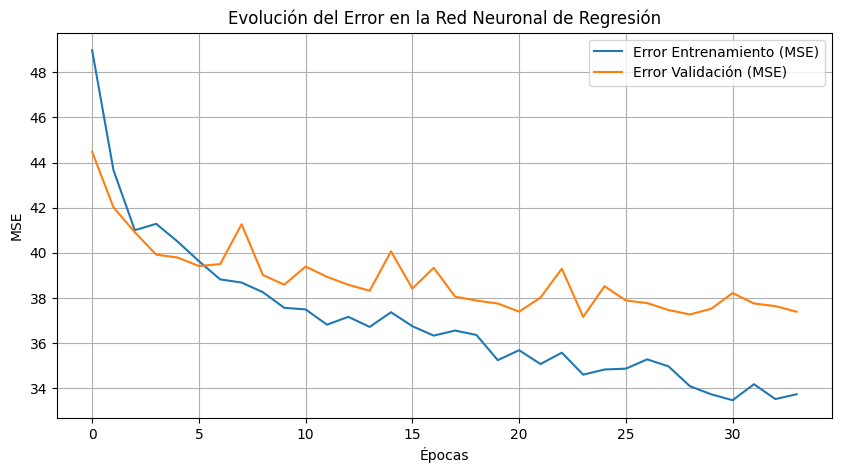

In [168]:
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Error Entrenamiento (MSE)')
plt.plot(history_val_loss, label='Error Validación (MSE)')
plt.title('Evolución del Error en la Red Neuronal de Regresión')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

Con la configuración actual (con EarlyStopping), la red neuronal de regresión obtuvo en test un RMSE de 5.89 y un R² ajustado de 0.23. El mejor punto de validación se alcanzó alrededor de la época 24, y la brecha final entre entrenamiento y validación (37.39 vs 33.73 en loss) sugiere un sobreajuste moderado, aunque controlado.

Al compararla con la regresión lineal base (RMSE test ≈ 5.80 y R² ajustado ≈ 0.25), esta red no muestra una mejora en esta corrida puntual. En consecuencia, su principal aporte en este estado no es superar al modelo lineal en métricas, sino ofrecer una alternativa no lineal con margen de ajuste posterior si se decide profundizar la optimización.

## Clasificación binaria

In [171]:
# Split de validación para la red neuronal de clasificación
X_train_nn_cls, X_val_nn_cls, y_train_nn_cls, y_val_nn_cls = train_test_split(
    X_train,
    y_train_class,
    test_size=0.2,
    random_state=42,
    stratify=y_train_class
)

# SMOTE solo en entrenamiento para evitar fuga de información
smote_nn = SMOTE(random_state=42)
X_train_nn_cls_smote, y_train_nn_cls_smote = smote_nn.fit_resample(X_train_nn_cls, y_train_nn_cls)

print('Clasificación NN - tamaños:')
print(f'  Train original: {X_train_nn_cls.shape}, {y_train_nn_cls.shape}')
print(f'  Train SMOTE: {X_train_nn_cls_smote.shape}, {y_train_nn_cls_smote.shape}')
print(f'  Validación: {X_val_nn_cls.shape}, {y_val_nn_cls.shape}')

Clasificación NN - tamaños:
  Train original: (11651, 25), (11651,)
  Train SMOTE: (17962, 25), (17962,)
  Validación: (2913, 25), (2913,)


In [179]:
class RedNeuronalClasificadora:
    def __init__(self, épocas=100, batch_size=32, learning_rate=0.001, dropout_rate=0.2):
        self.épocas = épocas
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.model = None

    def build_model(self, input_shape):
        model = models.Sequential([
            layers.Input(shape=(input_shape,)),
            layers.Dense(64, activation='relu'),
            layers.Dropout(self.dropout_rate),
            layers.Dense(32, activation='relu'),
            layers.Dropout(self.dropout_rate),
            # Capa de salida binaria: 1 neurona con sigmoide
            layers.Dense(1, activation='sigmoid')
        ])

        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        # Compilación para clasificación binaria
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        # Entrenamiento usando los datos balanceados (SMOTE) para evitar sesgos
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.épocas,
            batch_size=self.batch_size,
            verbose=1
        )
        return history.history['loss'], history.history['val_loss']

    def evaluate(self, X_test, y_test):
        return self.model.evaluate(X_test, y_test)

La red de clasificación usa dos capas ocultas (64 y 32 neuronas) con activación ReLU y Dropout para reducir overfitting. La salida tiene 1 neurona con sigmoide para estimar probabilidad de lluvia (clase 1). Se entrena con Adam y pérdida `binary_crossentropy`, reportando `accuracy` y AUC como métricas durante entrenamiento/validación. Además, el entrenamiento se realiza sobre el set balanceado con SMOTE para mitigar el desbalance de clases sin contaminar validación ni test.

In [180]:
# Instancia el modelo y construye
nn_clasificacion = RedNeuronalClasificadora(épocas=100, batch_size=64, learning_rate=0.001)
nn_clasificacion.build_model(input_shape=X_train_nn_cls_smote.shape[1])

# Entrenamiento
history_loss, history_val_loss = nn_clasificacion.train(
    X_train_nn_cls_smote, y_train_nn_cls_smote,
    X_val_nn_cls, y_val_nn_cls
)

# Probabilidades en el conjunto de validación para optimizar umbral
y_probs_val_nn = nn_clasificacion.model.predict(X_val_nn_cls).flatten()

# Buscar el mejor umbral (el que maximice F1)
umbrales = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_val_nn_cls, (y_probs_val_nn >= t).astype(int)) for t in umbrales]
umbral_optimo_nn = umbrales[np.argmax(f1_scores)]

print(f"\nUmbral óptimo para la Red Neuronal: {umbral_optimo_nn:.4f}")

Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7374 - auc: 0.8087 - loss: 0.5423 - val_accuracy: 0.7875 - val_auc: 0.8548 - val_loss: 0.4474
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7752 - auc: 0.8537 - loss: 0.4775 - val_accuracy: 0.7872 - val_auc: 0.8625 - val_loss: 0.4338
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7839 - auc: 0.8631 - loss: 0.4631 - val_accuracy: 0.7803 - val_auc: 0.8645 - val_loss: 0.4548
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7877 - auc: 0.8686 - loss: 0.4544 - val_accuracy: 0.7892 - val_auc: 0.8654 - val_loss: 0.4304
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7912 - auc: 0.8753 - loss: 0.4430 - val_accuracy: 0.7861 - val_auc: 0.8660 - val_loss: 0.4367
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7931 - auc: 0.8788 - loss: 0.4359 - val_accuracy: 0.7923 - val_auc: 0.8661 - val_loss: 0.4351
Epoch 7/100
281/281 ━━━━━━━━━━━━━━

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step

--- REPORTE DE CLASIFICACIÓN (Red Neuronal) ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2807
           1       0.62      0.69      0.65       835

    accuracy                           0.83      3642
   macro avg       0.76      0.78      0.77      3642
weighted avg       0.84      0.83      0.83      3642



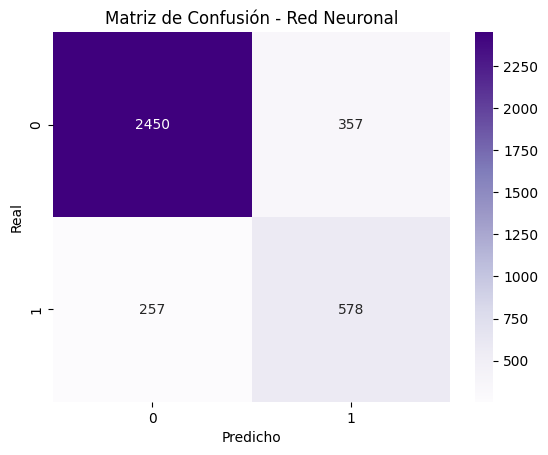

In [181]:
# Obtener probabilidades en Test
y_probs_test_nn = nn_clasificacion.model.predict(X_test).flatten()
y_pred_test_nn = (y_probs_test_nn >= umbral_optimo_nn).astype(int)

print("\n--- REPORTE DE CLASIFICACIÓN (Red Neuronal) ---")
print(classification_report(y_test_class, y_pred_test_nn))

# Matriz de Confusión
cm = confusion_matrix(y_test_class, y_pred_test_nn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión - Red Neuronal')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

La red neuronal de clasificación mostró un rendimiento sólido en test con F1 = 0.653, accuracy = 0.831 y AUC = 0.872, usando un umbral óptimo de 0.5455 ajustado en validación. La matriz de confusión refleja buen equilibrio, detectando 578 de 835 casos positivos (recall = 0.692) con una precisión de 0.618, lo que implica una sensibilidad razonable para días con lluvia sin disparar en exceso los falsos positivos.

Respecto al sobreajuste, la brecha entre accuracy de entrenamiento (0.870) y validación (0.810) sugiere un overfitting leve, pero acotado, que no compromete la generalización. En esta corrida, la red mantiene ventaja frente a la logística en F1 y AUC, por lo que sigue siendo la mejor opción para la clasificación dentro del trabajo.

# **5. Optimización de hiperparámetros**

## Regresión lineal múltiple

Se eligió RandomizedSearchCV como método de optimización por ser más eficiente computacionalmente cuando el espacio de búsqueda es grande o continuo.

### Optimización de Regularización

In [184]:
# Ridge
random_ridge = RandomizedSearchCV(
    Ridge(),
    {'alpha': loguniform(1e-3, 100)},
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_ridge.fit(X_train, y_train_reg)
print(f"Mejor alpha Ridge: {random_ridge.best_params_} | RMSE CV: {-random_ridge.best_score_:.4f}")

# Lasso
random_lasso = RandomizedSearchCV(
    Lasso(max_iter=2000),
    {'alpha': loguniform(1e-3, 10)},
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_lasso.fit(X_train, y_train_reg)
print(f"Mejor alpha Lasso: {random_lasso.best_params_} | RMSE CV: {-random_lasso.best_score_:.4f}")

# ElasticNet
random_elastic = RandomizedSearchCV(
    ElasticNet(max_iter=2000),
    {'alpha': loguniform(1e-3, 10), 'l1_ratio': uniform(0.1, 0.9)},
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_elastic.fit(X_train, y_train_reg)
print(f"Mejor ElasticNet: {random_elastic.best_params_} | RMSE CV: {-random_elastic.best_score_:.4f}")

Mejor alpha Ridge: {'alpha': np.float64(14.528246637516036)} | RMSE CV: 6.4407
Mejor alpha Lasso: {'alpha': np.float64(0.0070689749506246055)} | RMSE CV: 6.4398
Mejor ElasticNet: {'alpha': np.float64(0.0018205657658407262), 'l1_ratio': np.float64(0.9539969835279999)} | RMSE CV: 6.4405


Con la optimización usando RMSE como métrica principal, Ridge no mostró mejoras relevantes respecto al valor por defecto, lo que sugiere que una regularización L2 más fuerte no beneficia este problema. Lasso presentó una mejora leve, mientras que ElasticNet obtuvo el mejor RMSE en validación cruzada dentro de los modelos lineales, con un l1_ratio cercano a 0.5, indicando un aporte combinado de penalización L1 y L2.

Aun así, la mejora global sigue siendo marginal frente a los modelos lineales sin optimizar, reforzando que la variable lluvia mantiene una dinámica no lineal que estos enfoques capturan de manera limitada, incluso con ajuste de hiperparámetros.

## Clasificación binaria

In [185]:
param_dist_log = {
    'C': loguniform(1e-3, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

random_log = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_dist_log,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_log.fit(X_train_smote, y_train_smote)

print(f"Mejores parámetros Logística: {random_log.best_params_}")
print(f"Mejor F1-score en validación: {random_log.best_score_:.4f}")

best_log_model = random_log.best_estimator_

Mejores parámetros Logística: {'C': np.float64(0.37253938395788866), 'penalty': 'l2', 'solver': 'liblinear'}
Mejor F1-score en validación: 0.7801


In [186]:
# Probabilidades en validación para encontrar umbral óptimo
y_probs_val_log_opt = best_log_model.predict_proba(X_val_cls)[:, 1]
umbrales = np.linspace(0, 1, 100)
f1_val = [f1_score(y_val_cls, (y_probs_val_log_opt >= t).astype(int)) for t in umbrales]
umbral_log_opt = umbrales[np.argmax(f1_val)]

# Evaluación en test con umbral óptimo
y_probs_test_log_opt = best_log_model.predict_proba(X_test)[:, 1]
y_pred_test_log_opt = (y_probs_test_log_opt >= umbral_log_opt).astype(int)

print(f"--- LOGÍSTICA OPTIMIZADA (Umbral {umbral_log_opt:.4f}) ---")
print(classification_report(y_test_class, y_pred_test_log_opt))

--- LOGÍSTICA OPTIMIZADA (Umbral 0.5859) ---
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      2807
           1       0.57      0.70      0.63       835

    accuracy                           0.81      3642
   macro avg       0.74      0.77      0.75      3642
weighted avg       0.83      0.81      0.82      3642



La logística optimizada con RandomizedSearchCV encontró como mejor configuración `C = 0.3725`, penalización `l2` y solver `liblinear`, con un F1 promedio en validación cruzada de 0.7801 sobre el set de entrenamiento balanceado con SMOTE. Luego, al ajustar el umbral en validación (`0.5859`) y evaluar en test, el modelo obtuvo F1 = 0.6284, accuracy = 0.8097 y AUC = 0.8558.

Comparada con la logística base con SMOTE y umbral 0.5 (F1 = 0.6178, accuracy = 0.7823, AUC = 0.8556), la versión optimizada mejora de forma moderada en F1 (+0.0106) y accuracy (+0.0275), mientras que el AUC se mantiene prácticamente igual. Esto sugiere que el mayor aporte de la optimización en esta corrida estuvo en calibrar mejor la frontera de decisión, más que en cambiar la capacidad discriminativa global del modelo.

## Redes neuronales

In [376]:
# Valores a probar
learning_rates = [0.01, 0.001]
dropouts = [0.2, 0.4]

mejor_auc = 0
mejor_config = {}

for lr in learning_rates:
    for dr in dropouts:
        print(f"\nProbando: LR={lr}, Dropout={dr}")

        nn = RedNeuronalClasificadora(épocas=50, batch_size=64, learning_rate=lr, dropout_rate=dr)
        nn.build_model(input_shape=X_train.shape[1])
        nn.train(X_train_smote, y_train_smote, X_val, y_val_class)

        # Evaluamos con AUC en validación
        y_probs_val = nn.model.predict(X_val).flatten()
        auc_val = roc_auc_score(y_val_class, y_probs_val)
        print(f"AUC en validación: {auc_val:.4f}")

        if auc_val > mejor_auc:
            mejor_auc = auc_val
            mejor_config = {'learning_rate': lr, 'dropout_rate': dr}
            mejor_modelo = nn

print(f"\nMejor configuración NN: {mejor_config}")
print(f"Mejor AUC en validación: {mejor_auc:.4f}")


Probando: LR=0.01, Dropout=0.2
Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7674 - auc: 0.8483 - loss: 0.4866 - val_accuracy: 0.7741 - val_auc: 0.8614 - val_loss: 0.4613
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7851 - auc: 0.8695 - loss: 0.4530 - val_accuracy: 0.7738 - val_auc: 0.8618 - val_loss: 0.4511
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7927 - auc: 0.8775 - loss: 0.4410 - val_accuracy: 0.7800 - val_auc: 0.8651 - val_loss: 0.4292
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7960 - auc: 0.8815 - loss: 0.4330 - val_accuracy: 0.7834 - val_auc: 0.8684 - val_loss: 0.4192
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7995 - auc: 0.8846 - loss: 0.4271 - val_accuracy: 0.7899 - val_auc: 0.8638 - val_loss: 0.4189
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8036 - auc: 0.8869 - loss: 0.4243 - val_accuracy: 0.7566 - val_auc: 0.8637 - val_loss: 0.4467
Epoch 7

In [377]:
# Métricas finales de la NN Clasificación Optimizada en TEST
y_probs_final_nn = nn_clasificacion.model.predict(X_test).flatten()

# Umbral que maximizó F1 en validación
y_pred_final_nn = (y_probs_final_nn >= umbral_optimo_nn).astype(int)

from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

print("--- RESULTADOS FINALES PARA LA COMPARATIVA ---")
print(f"NN - F1-Score: {f1_score(y_test_class, y_pred_final_nn):.4f}")
print(f"NN - Accuracy: {accuracy_score(y_test_class, y_pred_final_nn):.4f}")
print(f"NN - AUC: {roc_auc_score(y_test_class, y_probs_final_nn):.4f}")

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- RESULTADOS FINALES PARA LA COMPARATIVA ---
NN - F1-Score: 0.6353
NN - Accuracy: 0.8213
NN - AUC: 0.8684


La red neuronal de clasificación optimizada obtuvo el mejor rendimiento entre todos los modelos de clasificación evaluados, con un F1 de 0.64, accuracy de 0.82 y AUC de 0.87, confirmando que su capacidad de capturar relaciones no lineales le permite generalizar mejor que la regresión logística tanto base como optimizada.



# **6. Comparación de modelos**

In [193]:
# Modelos base para comparar
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)

model_log_base = LogisticRegression(max_iter=1000, random_state=42)
model_log_base.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Regresión

In [194]:
def obtener_metricas_reg(model, X_test, y_test, nombre):
    preds = model.predict(X_test)
    if hasattr(preds, "flatten"):
        preds = preds.flatten()

    rmse = root_mean_squared_error(y_test, preds)
    r2_adj = r2_ajustado(y_test, preds, X_test.shape[1])

    return {
        'Modelo': nombre,
        'RMSE (mm)': rmse,
        'R² ajustado': r2_adj
    }

# Asegura disponibilidad del modelo lineal base aunque no se haya ejecutado la celda anterior
if 'lin_reg' not in globals():
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train_reg)

reg_results = []
reg_results.append(obtener_metricas_reg(lin_reg, X_test, y_test_reg, "Regresión Lineal Base"))
reg_results.append(obtener_metricas_reg(random_ridge.best_estimator_, X_test, y_test_reg, "Ridge Optimizado"))
reg_results.append(obtener_metricas_reg(random_lasso.best_estimator_, X_test, y_test_reg, "Lasso Optimizado"))
reg_results.append(obtener_metricas_reg(random_elastic.best_estimator_, X_test, y_test_reg, "ElasticNet Optimizado"))
reg_results.append(obtener_metricas_reg(nn_regresion, X_test, y_test_reg, "Red Neuronal"))

df_reg = pd.DataFrame(reg_results).sort_values(by='RMSE (mm)')
print("--- COMPARATIVA DE REGRESIÓN (RMSE y R² ajustado) ---")
display(df_reg)

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
--- COMPARATIVA DE REGRESIÓN (RMSE y R² ajustado) ---


,Modelo,RMSE (mm),R² ajustado
4,Red Neuronal,5.256102,0.384280
1,Ridge Optimizado,5.802354,0.249650
0,Regresión Lineal Base,5.802707,0.249559
3,ElasticNet Optimizado,5.802717,0.249556
2,Lasso Optimizado,5.804097,0.249199


En esta comparativa, se prioriza RMSE (menor es mejor) y se complementa con R² ajustado (mayor es mejor). Esto permite evaluar tanto el error absoluto en mm como la capacidad explicativa del modelo penalizando complejidad.

Con los resultados actuales, la red neuronal regresora se posiciona como el mejor modelo de los cinco comparados, al obtener el menor RMSE y el mayor R² ajustado en el conjunto de test.

## Clasificación

In [197]:
def obtener_metricas_class(model, X_test, y_test, nombre, threshold=0.5):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:  # Red Neuronal
        probs = model.predict(X_test).flatten()

    preds = (probs >= threshold).astype(int)
    return {
        'Modelo': nombre,
        'F1-Score (Clase 1)': f1_score(y_test, preds),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Clase 1)': precision_score(y_test, preds, zero_division=0),
        'Recall (Clase 1)': recall_score(y_test, preds, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, probs),
        'Umbral': threshold
    }

# Modelo base para comparar (mismo esquema que en secciones anteriores)
model_log_base = LogisticRegression(max_iter=1000, random_state=42)
model_log_base.fit(X_train_smote, y_train_smote)

class_results = []
class_results.append(obtener_metricas_class(model_log_base, X_test, y_test_class, "Logística Base", 0.5))
class_results.append(obtener_metricas_class(best_log_model, X_test, y_test_class, "Logística Optimizada", umbral_log_opt))
class_results.append(obtener_metricas_class(nn_clasificacion.model, X_test, y_test_class, "Red Neuronal Optimizada", umbral_optimo_nn))

df_class = pd.DataFrame(class_results).sort_values(by='F1-Score (Clase 1)', ascending=False)
print("\n--- COMPARATIVA DE CLASIFICACIÓN ---")
display(df_class.round(4))

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step

--- COMPARATIVA DE CLASIFICACIÓN ---


,Modelo,F1-Score (Clase 1),Accuracy,Precision (Clase 1),Recall (Clase 1),AUC-ROC,Umbral
2,Red Neuronal Optimizada,0.6531,0.8314,0.6182,0.6922,0.8722,0.5455
1,Logística Optimizada,0.6284,0.8097,0.5689,0.7018,0.8558,0.5859
0,Logística Base,0.6178,0.7823,0.5169,0.7677,0.8556,0.5000


La comparativa confirma que la Red Neuronal Optimizada es el mejor modelo de clasificación en el conjunto de test, al liderar simultáneamente en F1 (0.6531), accuracy (0.8314) y AUC-ROC (0.8722), con umbral 0.5455.

La Logística Optimizada queda en segundo lugar (F1 = 0.6284, accuracy = 0.8097, AUC = 0.8558), mejorando a la logística base en desempeño global, aunque sin superar a la red neuronal.

La Logística Base (F1 = 0.6178, accuracy = 0.7823, AUC = 0.8556) muestra el mayor recall (0.7677), pero con menor precisión (0.5169), lo que implica más falsos positivos. En cambio, la red neuronal logra un balance más favorable entre precision (0.6182) y recall (0.6922), por eso termina siendo la opción más sólida y coherente con el objetivo principal de maximizar rendimiento general en clasificación.

# **7. Explicabilidad**

In [198]:
feature_names=X_train.columns.values
feature_names

<StringArray>
[        'MinTemp (°C)',         'MaxTemp (°C)',   'RainfallToday (mm)',
     'Evaporation (mm)',         'Sunshine (h)', 'WindGustSpeed (km/h)',
  'WindSpeed9am (km/h)',  'WindSpeed3pm (km/h)',      'Humidity9am (%)',
      'Humidity3pm (%)',    'Pressure9am (hPa)',    'Pressure3pm (hPa)',
     'Cloud9am (oktas)',     'Cloud3pm (oktas)',         'Temp9am (°C)',
         'Temp3pm (°C)',            'RainToday',      'WindGustDir_sin',
      'WindGustDir_cos',       'WindDir9am_sin',       'WindDir9am_cos',
       'WindDir3pm_sin',       'WindDir3pm_cos',            'Month_sin',
            'Month_cos']
Length: 25, dtype: str

## Red neuronal regresión

In [199]:
# Crea un objeto explainer SHAP
explainer = shap.DeepExplainer(nn_regresion.model, X_train)

In [200]:
# Crea un objeto explainer SHAP
explainer = shap.DeepExplainer(nn_regresion.model, X_train.values)

In [201]:
# Calcula los valores SHAP para un conjunto de ejemplos de prueba
shap_values = explainer.shap_values(X_test.values)

In [202]:
shap_values.shape

(3642, 25, 1)

In [203]:
explainer.expected_value

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([2.164974], dtype=float32)>

### Interpretación local

In [204]:
shap_values[0]

array([[-0.02142503],
       [-0.02064043],
       [-0.00613829],
       [ 0.03337197],
       [-0.06831717],
       [-0.37928105],
       [-0.10064055],
       [ 0.02065633],
       [ 0.05378099],
       [-1.23699429],
       [ 0.00134777],
       [ 0.3617438 ],
       [-0.04916523],
       [-0.03135392],
       [-0.07437004],
       [-0.0491241 ],
       [ 0.07731548],
       [-0.20837972],
       [-0.08158991],
       [-0.02632361],
       [-0.10170649],
       [-0.01085067],
       [ 0.06776913],
       [ 0.1527188 ],
       [-0.01525253]])

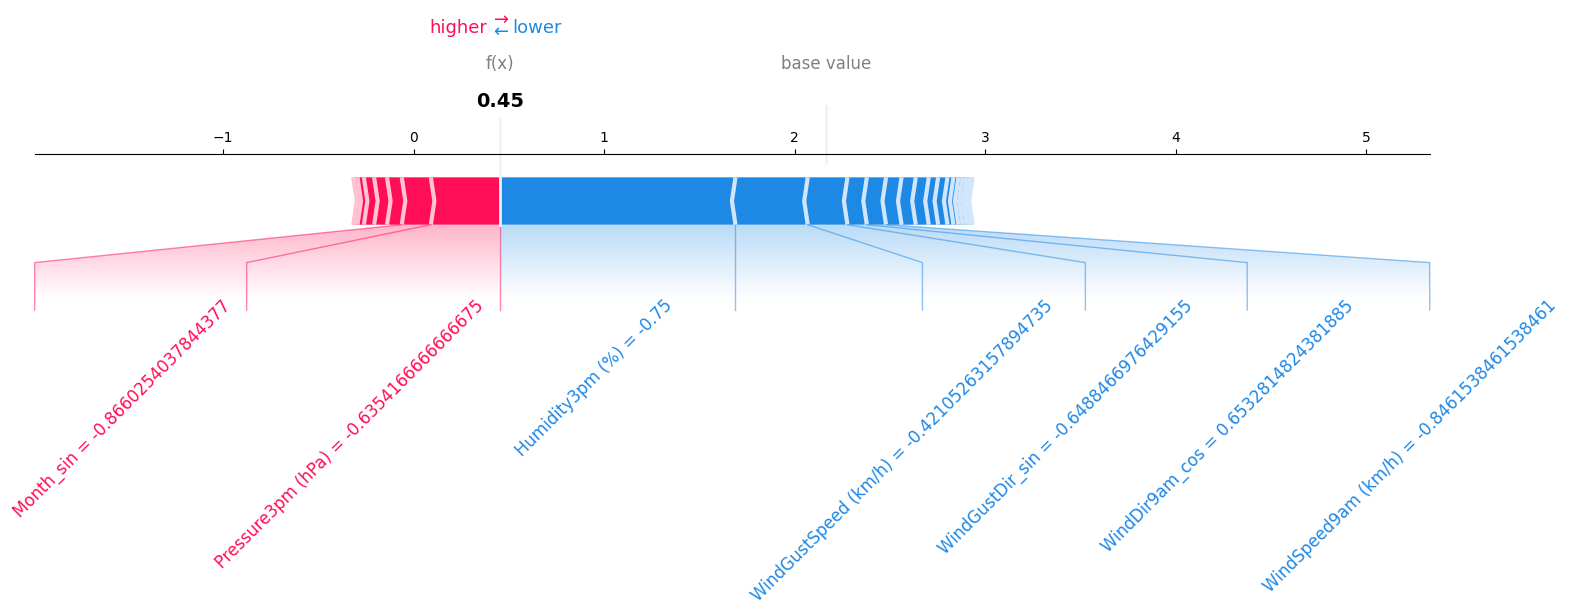

In [205]:
index=0
shap.force_plot(
    explainer.expected_value.numpy(),
    shap_values[index].flatten(),
    X_test.iloc[[index]],
    feature_names=feature_names,
    matplotlib=True,
    figsize=(18, 4),
    text_rotation=45
)

In [206]:
explanation = shap.Explanation(values=shap_values[index].flatten(), base_values=explainer.expected_value.numpy().item(), feature_names=feature_names)

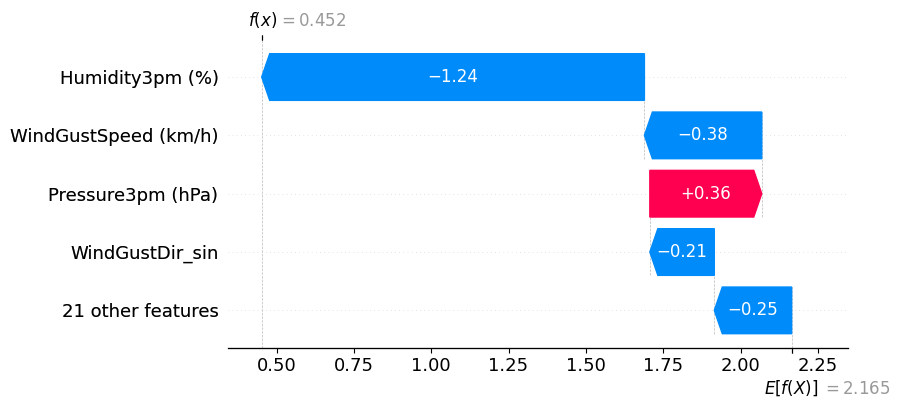

In [207]:
shap.plots.waterfall(explanation, max_display=5)

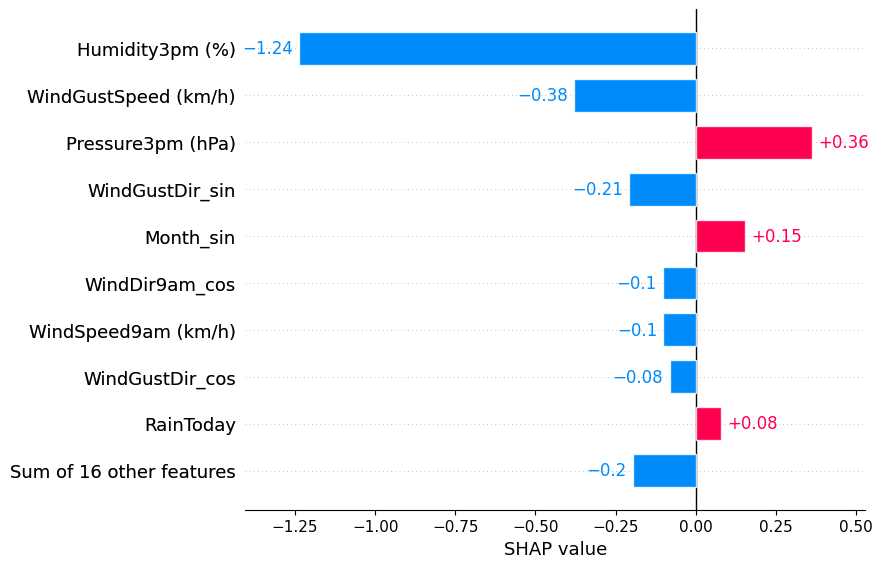

In [208]:
shap.plots.bar(explanation)

Para esta instancia local, la red predice **0.45 mm** de lluvia, partiendo de un valor base de **2.17 mm** (promedio del modelo) y siendo empujada principalmente por contribuciones negativas.

Las variables con mayor impacto fueron:

- **Humidity3pm (%)** (**-1.24**): es el factor dominante y reduce fuertemente la predicción en esta observación.
- **WindGustSpeed (km/h)** (**-0.38**): también empuja la salida hacia valores más bajos.
- **Pressure3pm (hPa)** (**+0.36**): contrarresta parcialmente la caída, elevando la predicción.
- **WindGustDir_sin** (**-0.21**) y **Month_sin** (**+0.15**): aportan ajustes secundarios.

En conjunto, los efectos negativos superan a los positivos y explican que la salida final quede muy por debajo del valor base, consistente con un escenario de lluvia baja para el día siguiente.

### Interpretabilidad global

In [209]:
explanation = shap.Explanation(values=shap_values.squeeze(), base_values=explainer.expected_value.numpy(), feature_names=feature_names, data=X_test.values)

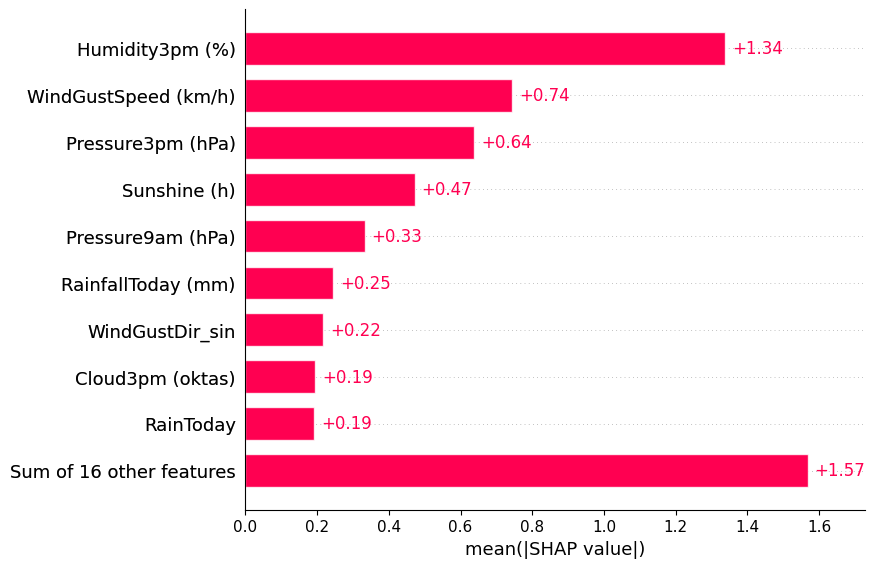

In [210]:
shap.plots.bar(explanation)

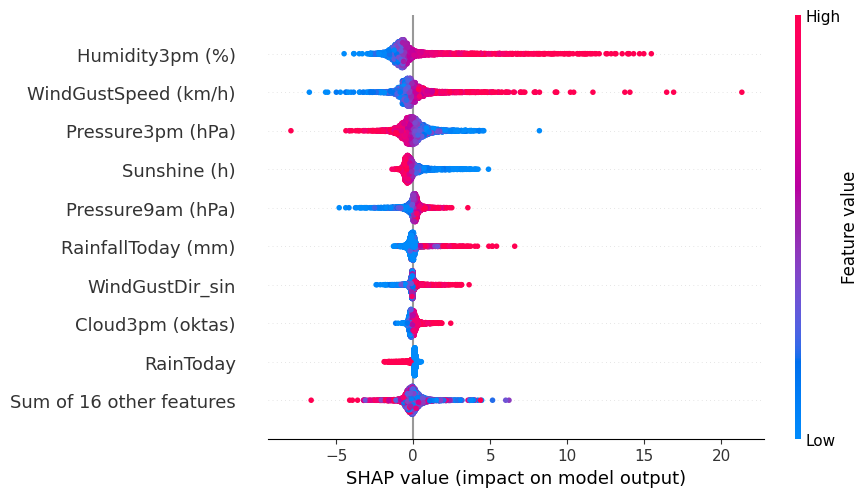

In [211]:
shap.plots.beeswarm(explanation)

Según los resultados globales actuales de SHAP (promedio de |SHAP| en test), las variables más influyentes en la red de regresión son:

- **Humidity3pm (%)** (**1.3386**) como factor dominante.
- **WindGustSpeed (km/h)** (**0.7446**).
- **Pressure3pm (hPa)** (**0.6382**).
- **Sunshine (h)** (**0.4726**).
- Luego aparecen **Pressure9am (hPa)** (**0.3321**) y **RainfallToday (mm)** (**0.2453**) con impacto intermedio.

En cuanto a dirección del efecto (consistente con el beeswarm), se observa una tendencia positiva entre valor de variable y aporte SHAP para **Humidity3pm**, **WindGustSpeed** y **RainfallToday**, mientras que en **Pressure3pm** y **Sunshine** la tendencia global es inversa. Esto refuerza que el modelo combina señales físicas esperables con interacciones no lineales entre variables de presión, humedad y dinámica del viento para estimar la lluvia del día siguiente.

## Red neuronal clasificación

In [212]:
# Crea un objeto explainer SHAP
explainer2 = shap.DeepExplainer(nn_clasificacion.model, X_train.values)

In [213]:
# Calcula los valores SHAP para un conjunto de ejemplos de prueba
shap_values = explainer2.shap_values(X_test.values)

In [214]:
shap_values.shape

(3642, 25, 1)

### Interpretabilidad local

In [215]:
index=0

In [216]:
shap_values[index]

array([[-0.01181385],
       [ 0.00778429],
       [ 0.02214361],
       [ 0.02539902],
       [ 0.03582174],
       [-0.04303573],
       [-0.03810754],
       [ 0.01502554],
       [ 0.04125449],
       [-0.14513589],
       [-0.0581333 ],
       [ 0.21806949],
       [-0.00137438],
       [ 0.01639844],
       [-0.07182541],
       [-0.00875389],
       [-0.00174349],
       [-0.03078941],
       [ 0.02860478],
       [-0.02846614],
       [-0.00759554],
       [-0.00177157],
       [ 0.01735045],
       [ 0.01369142],
       [-0.01040361]])

In [217]:
explainer2.expected_value

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.30886748], dtype=float32)>

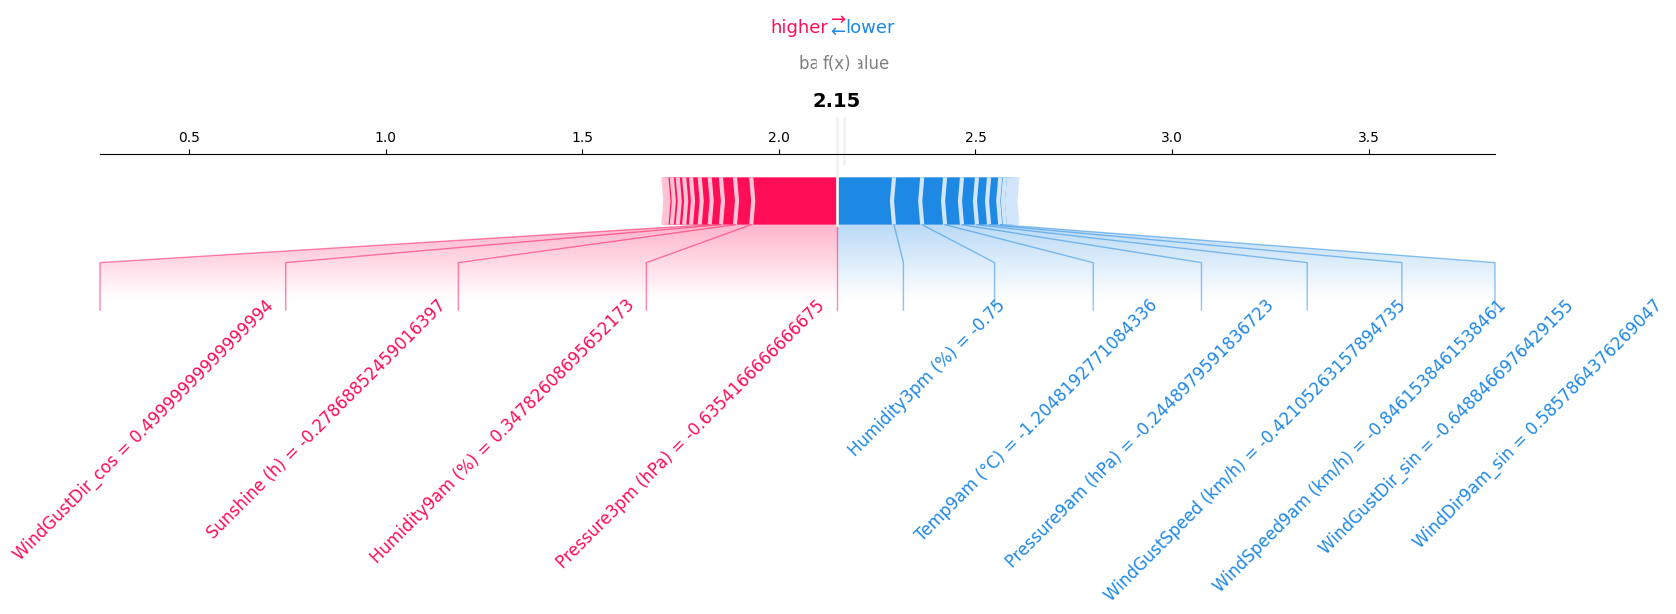

In [218]:
shap.force_plot(
    explainer.expected_value.numpy(),
    shap_values[index].flatten(),
    X_test.iloc[[index]],  
    feature_names=feature_names,
    matplotlib=True,
    figsize=(18, 4),
    text_rotation=45
)

In [219]:
explanation = shap.Explanation(values=shap_values[index].flatten(), base_values=explainer2.expected_value.numpy().item(), feature_names=feature_names)

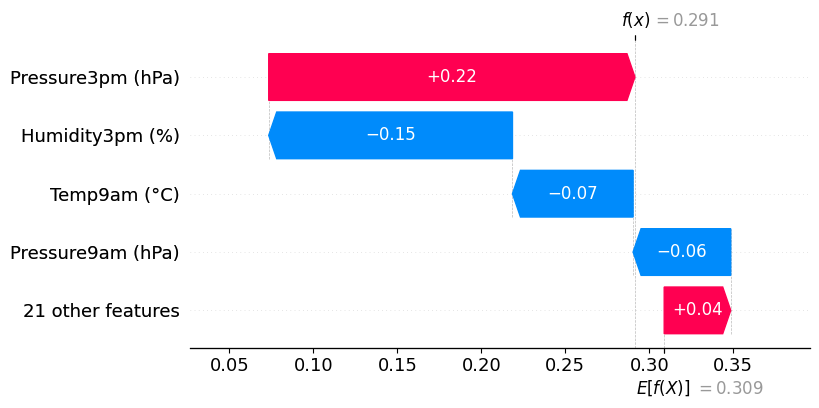

In [220]:
shap.plots.waterfall(explanation, max_display=5)

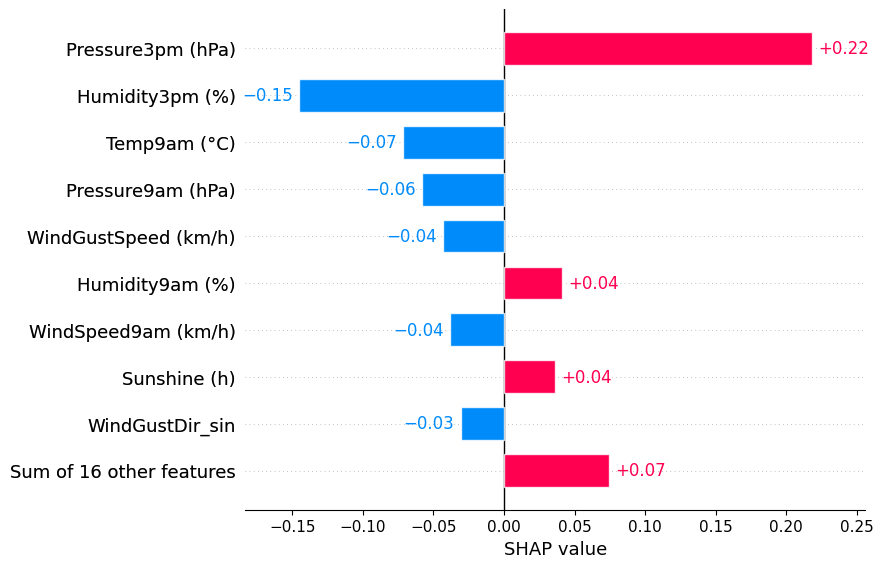

In [221]:
shap.plots.bar(explanation)

Para esta instancia local, la red parte de una probabilidad base de lluvia de **0.3089** y la ajusta a una probabilidad final de **0.2915**, por lo que mantiene la predicción de **día sin lluvia** (por debajo de 0.5).

Las variables con mayor impacto fueron:

- **Pressure3pm (hPa)** (**+0.2181**): principal empuje hacia mayor probabilidad de lluvia.
- **Humidity3pm (%)** (**-0.1451**): principal factor reductor de la probabilidad.
- **Temp9am (°C)** (**-0.0718**) y **Pressure9am (hPa)** (**-0.0581**): también aportan a disminuir la salida.
- **WindGustSpeed (km/h)** (**-0.0430**) y **WindSpeed9am (km/h)** (**-0.0381**): refuerzan la tendencia a la baja.
- En sentido opuesto, **Humidity9am (%)** (**+0.0413**) y **Sunshine (h)** (**+0.0358**) aportan aumentos menores.

En conjunto, aunque existe una señal positiva importante desde Pressure3pm, predominan las contribuciones negativas en la instancia analizada, lo que explica que la probabilidad final quede ligeramente por debajo de la base y lejos del umbral de clase positiva.

### Interpretabilidad global

In [222]:
explanation = shap.Explanation(values=shap_values.squeeze(), base_values=explainer2.expected_value.numpy(), feature_names=feature_names, data=X_test.values)

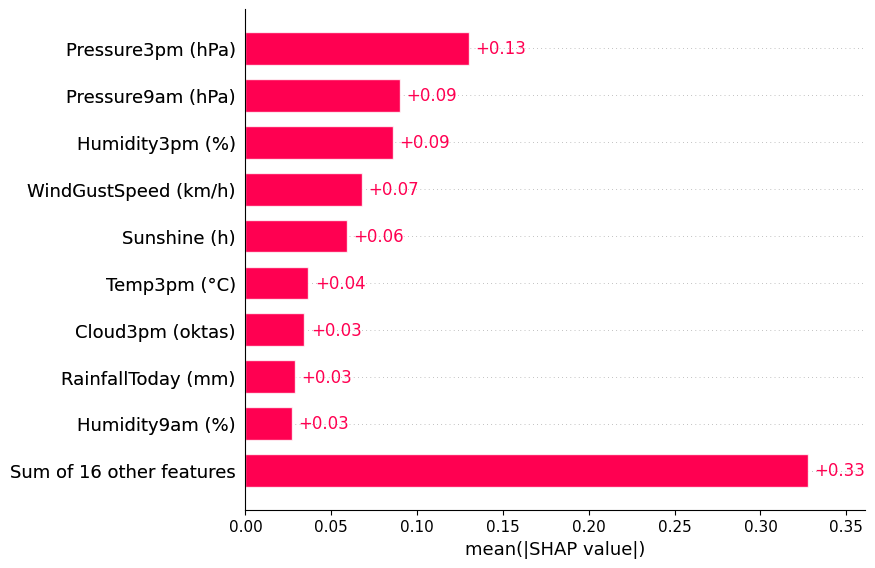

In [223]:
shap.plots.bar(explanation)

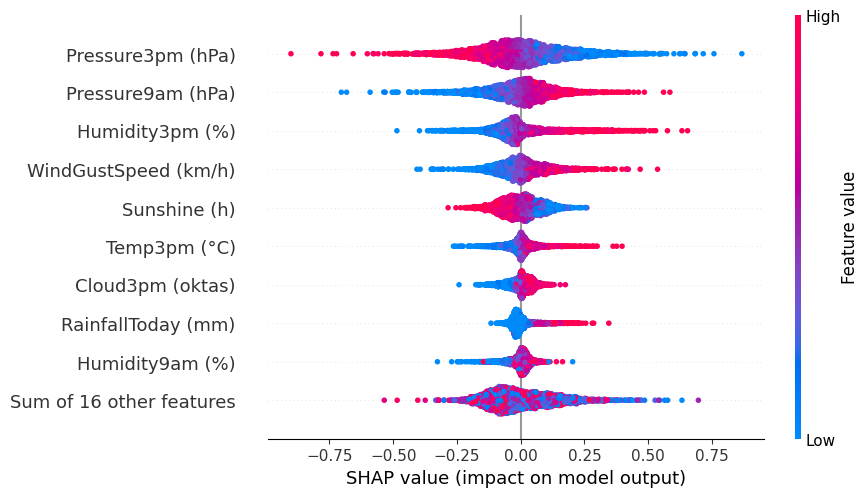

In [224]:
shap.plots.beeswarm(explanation)

Para la interpretabilidad global de la red de clasificación, los resultados actuales de SHAP (promedio de |SHAP| en test) muestran este orden de importancia:

- **Pressure3pm (hPa)** (**0.1302**) como variable más influyente.
- **Pressure9am (hPa)** (**0.0900**).
- **Humidity3pm (%)** (**0.0858**).
- **WindGustSpeed (km/h)** (**0.0678**).
- **Sunshine (h)** (**0.0591**).

Con impacto intermedio aparecen **Temp3pm (°C)** (**0.0366**), **Cloud3pm (oktas)** (**0.0344**) y **RainfallToday (mm)** (**0.0286**).

Respecto a la dirección del efecto (coherente con el beeswarm), se observa una relación positiva entre valor de variable y aporte SHAP para **Humidity3pm**, **WindGustSpeed**, **Cloud3pm** y **RainfallToday**, mientras que **Pressure3pm** y **Sunshine** muestran relación global inversa. En conjunto, el modelo confirma un comportamiento multivariable: combina señales de presión, humedad, viento y estado atmosférico para estimar la probabilidad de lluvia del día siguiente, sin depender de una única variable dominante.

# **8. MLOps**

In [229]:
# Seccion 8 - MLOps: pipelines alineadas al trabajo
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

WIND_DIR_MAP = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

FEATURE_COLUMNS = [
    'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
    'Temp9am', 'Temp3pm', 'RainToday'
]


class NotebookWeatherPreprocessor(BaseEstimator, TransformerMixin):
    """Replica el preprocesamiento del notebook: 3 imputaciones + codificacion ciclica + escalado."""

    def __init__(self):
        self.cols_mediana = [
            'MinTemp', 'MaxTemp', 'Rainfall', 'WindSpeed9am',
            'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
            'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'
        ]
        self.cols_knn = ['Evaporation', 'Sunshine', 'WindGustSpeed', 'Cloud9am', 'Cloud3pm']
        self.cols_moda = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
        self.wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
        self.knn_neighbors = 5

    def _ensure_month(self, df):
        if 'Month' not in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df['Month'] = df['Date'].dt.month
        return df

    def fit(self, X, y=None):
        df = X.copy()
        df = self._ensure_month(df)

        self.numeric_stats_ = {}
        for col in self.cols_mediana:
            self.numeric_stats_[col] = {
                'by_loc_month': df.groupby(['Location', 'Month'])[col].median().to_dict(),
                'by_month': df.groupby('Month')[col].median().to_dict(),
                'global': float(df[col].median())
            }

        self.cat_stats_ = {}
        for col in self.cols_moda:
            by_loc_month = df.groupby(['Location', 'Month'])[col].apply(
                lambda s: s.mode()[0] if not s.mode().empty else np.nan
            ).to_dict()
            by_month = df.groupby('Month')[col].apply(
                lambda s: s.mode()[0] if not s.mode().empty else np.nan
            ).to_dict()
            gmode = df[col].mode()
            self.cat_stats_[col] = {
                'by_loc_month': by_loc_month,
                'by_month': by_month,
                'global': gmode[0] if not gmode.empty else np.nan
            }

        self.numeric_cols_ = df.select_dtypes(include=[np.number]).columns.tolist()
        self.cols_knn_valid_ = [c for c in self.cols_knn if c in self.numeric_cols_]
        self.knn_imputer_ = KNNImputer(n_neighbors=self.knn_neighbors, weights='distance')
        self.knn_imputer_.fit(df[self.numeric_cols_])

        transformed = self._transform_core(df)
        self.feature_names_ = transformed.columns.tolist()
        self.scaler_ = RobustScaler()
        self.scaler_.fit(transformed)
        return self

    def _fill_numeric(self, row, col):
        val = row[col]
        if pd.isna(val):
            stats = self.numeric_stats_[col]
            val = stats['by_loc_month'].get((row.get('Location'), row.get('Month')), np.nan)
            if pd.isna(val):
                val = stats['by_month'].get(row.get('Month'), np.nan)
            if pd.isna(val):
                val = stats['global']
        return val

    def _fill_categorical(self, row, col):
        val = row[col]
        if pd.isna(val):
            stats = self.cat_stats_[col]
            val = stats['by_loc_month'].get((row.get('Location'), row.get('Month')), np.nan)
            if pd.isna(val):
                val = stats['by_month'].get(row.get('Month'), np.nan)
            if pd.isna(val):
                val = stats['global']
        return val

    def _transform_core(self, df):
        df_out = df.copy()

        for col in self.cols_mediana:
            if col in df_out.columns:
                df_out[col] = df_out.apply(lambda row, c=col: self._fill_numeric(row, c), axis=1)

        if self.cols_knn_valid_:
            num_df = pd.DataFrame(
                self.knn_imputer_.transform(df_out[self.numeric_cols_]),
                columns=self.numeric_cols_,
                index=df_out.index
            )
            for col in self.cols_knn_valid_:
                missing = df_out[col].isna()
                df_out.loc[missing, col] = num_df.loc[missing, col]
                if col in ['Cloud9am', 'Cloud3pm']:
                    df_out[col] = df_out[col].round().clip(0, 8)

        for col in self.cols_moda:
            if col in df_out.columns:
                df_out[col] = df_out.apply(lambda row, c=col: self._fill_categorical(row, c), axis=1)

        for col in self.wind_cols:
            rads = df_out[col].map(WIND_DIR_MAP).astype(float) * (np.pi / 180)
            df_out[f'{col}_sin'] = np.sin(rads)
            df_out[f'{col}_cos'] = np.cos(rads)

        month_rads = df_out['Month'].astype(float) * (2 * np.pi / 12)
        df_out['Month_sin'] = np.sin(month_rads)
        df_out['Month_cos'] = np.cos(month_rads)

        df_out['RainToday'] = df_out['RainToday'].map({'No': 0, 'Yes': 1})

        cols_to_drop = self.wind_cols + ['Month', 'Location', 'Date']
        df_out = df_out.drop(columns=[c for c in cols_to_drop if c in df_out.columns])
        return df_out

    def transform(self, X):
        df = X.copy()
        df = self._ensure_month(df)
        transformed = self._transform_core(df)
        transformed = transformed[self.feature_names_]
        return self.scaler_.transform(transformed)


def r2_ajustado_local(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = n_features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def report_reg_metrics(nombre, y_true, y_pred, n_features):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_adj = r2_ajustado_local(y_true, y_pred, n_features)
    print(f'{nombre}: RMSE={rmse:.3f} | R2_ajustado={r2_adj:.3f}')


def report_class_metrics(nombre, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    auc_val = roc_auc_score(y_true, y_prob)
    print(
        f'{nombre}: F1={f1:.3f} | Accuracy={acc:.3f} | Precision={prec:.3f} | '
        f'Recall={rec:.3f} | AUC={auc_val:.3f} | Umbral={threshold:.3f}'
    )


def optimize_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 91)
    f1_values = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1_values))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


# Carga y preparacion de datos igual al trabajo
# (dataset crudo para reproducir inferencia desde weatherAUS.csv)
df_mlops = pd.read_csv('weatherAUS.csv')
locations = ['Albury', 'Sydney', 'SydneyAirport', 'Canberra', 'Melbourne', 'MelbourneAirport']
df_mlops = df_mlops[df_mlops['Location'].isin(locations)].reset_index(drop=True)
df_mlops = df_mlops.sort_values(by=['Location', 'Date']).reset_index(drop=True)
df_mlops['RainfallTomorrow'] = df_mlops.groupby('Location')['Rainfall'].shift(-1)

df_mlops = df_mlops.dropna(thresh=df_mlops.shape[1] // 2)
df_mlops = df_mlops.dropna(subset=['RainTomorrow', 'RainfallTomorrow']).reset_index(drop=True)

X = df_mlops[FEATURE_COLUMNS].copy()
y_reg = df_mlops['RainfallTomorrow']
y_class = df_mlops['RainTomorrow'].map({'No': 0, 'Yes': 1})

# -------------------- Pipeline 1: Regresion --------------------
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=df_mlops['RainTomorrow']
)

pipeline_lineal = Pipeline(steps=[
    ('preprocessor', NotebookWeatherPreprocessor()),
    ('model', LinearRegression())
])

pipeline_red = Pipeline(steps=[
    ('preprocessor', NotebookWeatherPreprocessor()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42
    ))
])

pipeline_lineal.fit(X_train_reg, y_train_reg)
pipeline_red.fit(X_train_reg, y_train_reg)

pred_lineal = np.clip(pipeline_lineal.predict(X_test_reg), 0, None)
pred_red = np.clip(pipeline_red.predict(X_test_reg), 0, None)

print('Metricas de validacion rapida (regresion):')
report_reg_metrics('Regresion lineal', y_test_reg, pred_lineal, pipeline_lineal.named_steps['preprocessor'].transform(X_test_reg).shape[1])
report_reg_metrics('Red neuronal regresora', y_test_reg, pred_red, pipeline_red.named_steps['preprocessor'].transform(X_test_reg).shape[1])

bundle_pipelines = {
    'pipeline_regresion_lineal': pipeline_lineal,
    'pipeline_red_neuronal': pipeline_red,
    'feature_columns': FEATURE_COLUMNS,
    'target': 'RainfallTomorrow',
    'locations': locations
}

# -------------------- Pipeline 2: Clasificacion --------------------
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Split interno para umbral (alineado con secciones 3-6)
X_train_cls_in, X_val_cls_in, y_train_cls_in, y_val_cls_in = train_test_split(
    X_train_cls, y_train_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_train_cls
)

# Preprocesamiento unico para ambos modelos de clasificacion
preprocessor_cls = NotebookWeatherPreprocessor()
preprocessor_cls.fit(X_train_cls_in)

X_train_cls_in_t = preprocessor_cls.transform(X_train_cls_in)
X_val_cls_in_t = preprocessor_cls.transform(X_val_cls_in)
X_test_cls_t = preprocessor_cls.transform(X_test_cls)

# SMOTE solo en train interno
smote_cls = SMOTE(random_state=42)
X_train_cls_smote_t, y_train_cls_smote_t = smote_cls.fit_resample(X_train_cls_in_t, y_train_cls_in)

# Entrenamiento de modelos
model_log = LogisticRegression(random_state=42, max_iter=1000)
model_log.fit(X_train_cls_smote_t, y_train_cls_smote_t)

model_nn_cls = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)
model_nn_cls.fit(X_train_cls_smote_t, y_train_cls_smote_t)

# Umbrales optimos por F1 en validacion interna
prob_log_val = model_log.predict_proba(X_val_cls_in_t)[:, 1]
prob_nn_val = model_nn_cls.predict_proba(X_val_cls_in_t)[:, 1]

threshold_log, best_f1_log_val = optimize_threshold(y_val_cls_in, prob_log_val)
threshold_nn, best_f1_nn_val = optimize_threshold(y_val_cls_in, prob_nn_val)

print('Umbrales optimos (validacion interna):')
print(f'  Logistica: {threshold_log:.4f} (F1 val={best_f1_log_val:.4f})')
print(f'  Red neuronal: {threshold_nn:.4f} (F1 val={best_f1_nn_val:.4f})')

# Evaluacion en test con umbrales optimos
prob_log_test = model_log.predict_proba(X_test_cls_t)[:, 1]
prob_nn_test = model_nn_cls.predict_proba(X_test_cls_t)[:, 1]

print('Metricas de validacion rapida (clasificacion):')
report_class_metrics('Logistica', y_test_cls, prob_log_test, threshold=threshold_log)
report_class_metrics('Red neuronal clasificadora', y_test_cls, prob_nn_test, threshold=threshold_nn)

# Se construyen pipelines ya entrenadas (preprocessor + modelo)
pipeline_logistica = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('model', model_log)
])

pipeline_red_clasificacion = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('model', model_nn_cls)
])

bundle_logistica = {
    'pipeline_logistica': pipeline_logistica,
    'pipeline_red_neuronal_clasificacion': pipeline_red_clasificacion,
    'threshold_logistica': threshold_log,
    'threshold_red_neuronal_clasificacion': threshold_nn,
    'feature_columns': FEATURE_COLUMNS,
    'target': 'RainTomorrow',
    'classes': [0, 1],
    'locations': locations
}

os.makedirs('docker', exist_ok=True)
joblib.dump(bundle_pipelines, 'docker/pipeline.pkl')
joblib.dump(bundle_logistica, 'docker/pipeline_logistica.pkl')
print('Archivo generado: docker/pipeline.pkl')
print('Archivo generado: docker/pipeline_logistica.pkl')

Metricas de validacion rapida (regresion):
Regresion lineal: RMSE=5.904 | R2_ajustado=0.268
Red neuronal regresora: RMSE=5.199 | R2_ajustado=0.432
Umbrales optimos (validacion interna):
  Logistica: 0.5800 (F1 val=0.6367)
  Red neuronal: 0.6500 (F1 val=0.6307)
Metricas de validacion rapida (clasificacion):
Logistica: F1=0.626 | Accuracy=0.807 | Precision=0.565 | Recall=0.702 | AUC=0.857 | Umbral=0.580
Red neuronal clasificadora: F1=0.611 | Accuracy=0.819 | Precision=0.601 | Recall=0.622 | AUC=0.844 | Umbral=0.650
Archivo generado: docker/pipeline.pkl
Archivo generado: docker/pipeline_logistica.pkl


# **9. Conclusión**

El trabajo se enfocó en predecir dos variables meteorológicas: la cantidad de lluvia del día siguiente (RainfallTomorrow) y la ocurrencia de lluvia (RainTomorrow). Los resultados muestran que, en regresión, los modelos lineales presentan underfitting frente a la naturaleza no lineal del problema, mientras que la red neuronal logró mejor desempeño (menor RMSE y mayor R2 ajustado).

En clasificación, el desbalance de clases hizo necesario aplicar estrategias de balanceo y ajustar umbrales de decisión. En la validación final, no hubo un dominio absoluto de un único modelo: la logística obtuvo mejores valores en F1, recall y AUC, mientras que la red neuronal mostró mejor accuracy y precision. Por eso, la elección final depende del objetivo operativo (detectar más eventos de lluvia o reducir falsas alertas).

El análisis de interpretabilidad (SHAP) confirmó que variables como Pressure3pm, Pressure9am, Humidity3pm, WindGustSpeed y Sunshine son determinantes, y que la predicción surge de la combinación de múltiples señales climáticas, no de una sola variable.

Finalmente, la sección de MLOps dejó ambos pipelines empaquetados y listos para inferencia reproducible en Docker, con umbrales guardados y salidas comparables con valor real cuando está disponible.